# 미니프로젝트 6: Day 1~6 통합 복습 (Vibe Coding)

#### <목표>
Day1 ~ 6에서 배운 머신러닝 프로세스 전체를 새로운 데이터셋(신용카드 고객 채무불이행)에 자유롭게 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Default of Credit Card Clients (대만 신용카드 고객 채무불이행 데이터)
- 30,000명의 신용카드 고객 정보로 다음 달 채무불이행 여부를 예측

| 변수명 | 설명 |
|:---:|:---|
| LIMIT_BAL | 신용한도 |
| SEX, EDUCATION, MARRIAGE, AGE | 고객 인적사항 |
| PAY_0, PAY_2~PAY_6 | 최근 6개월 월별 연체 상태 (-1: 정상납부, 1 이상: 연체 개월 수) |
| BILL_AMT1~6 | 최근 6개월 청구액 |
| PAY_AMT1~6 | 최근 6개월 납부액 |
| default payment next month | 다음 달 채무불이행 여부 (1: 불이행, 0: 정상) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `default payment next month` | 고객 정보로 다음 달 채무불이행 여부 예측 |

1. 각 섹션의 **과제**를 읽고, Day1~6 중 어떤 내용을 적용해야 할지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day6_miniproject.csv` 파일을 사용하기
- 타겟 변수: `default payment next month` (0: 정상, 1: 채무불이행)

**[과제]** 써니는 신용카드 고객 채무불이행 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리와 데이터를 불러오는 코드를 AI와 상의해서 작성하세요.

In [ ]:
!pip install xgboost lightgbm catboost imbalanced-learn shap boruta mrmr-selection

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 한글 그래프 깨짐 방지 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== 데이터 분할 / 검증 / 튜닝 (Day 8~10) =====
from sklearn.model_selection import (
    train_test_split, cross_validate,
    GridSearchCV, RandomizedSearchCV
)

# ===== 전처리 (Day 8, 11, 12) =====
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import KNNImputer

# ===== 단일 분류 모델 (Day 8~9) =====
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ===== 앙상블 분류 모델 (Day 10) =====
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ===== 평가 지표 (Day 8~10) =====
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# ===== 클래스 불균형 처리 (Day 11) =====
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek
from sklearn.svm import OneClassSVM

# ===== 변수 선택 / 해석 (Day 12, 13) =====
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import shap

# ===== 원본 데이터 불러오기 =====
df = pd.read_csv("dataset/day6_miniproject.csv")

# 타겟 변수 (노트북 기준)
TARGET = "Churn"

# ID 컬럼이 있으면 제거 (모델링에 불필요)
id_cols = [col for col in df.columns if col.lower() in ["id", "customerid"]]
if id_cols:
    df = df.drop(columns=id_cols)

print("데이터 shape:", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())

display(df.head())
df.info()
df[TARGET]

데이터 shape: (7043, 20)

컬럼 목록:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

## 1) 데이터 탐색 (EDA)

1. Value 기반 탐색 (구조적/통계적)
2. Graph 기반 탐색 (단일 변수/변수 간/여러 변수 간)

**[과제]** 써니는 모델링을 수행하기 전에 필요한 전처리 과정을 파악하기 위해 데이터 탐색(EDA)이 필요하다고 생각했습니다.

AI와 상의하여 데이터의 구조적 정보(변수 타입, 결측치 유무 등)와 통계적 정보(변수별 고유값 개수, 기초통계량 등)를 확인하는 코드를 작성하고, 결과를 분석해 보세요.


In [5]:
TARGET = "Churn"

df_eda = df.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")

print("데이터 크기:", df_eda.shape)
print("\n컬럼 목록:")
print(df_eda.columns.tolist())

print("\n데이터 타입:")
print(df_eda.dtypes.to_string())

print("\n결측치 개수:")
print(df_eda.isnull().sum().to_string())

print(f"\n타겟 변수({TARGET}) 분포:")
print(df_eda[TARGET].value_counts().to_string())

데이터 크기: (7043, 20)

컬럼 목록:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

데이터 타입:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object

결측치 개수:
gender               0
SeniorCitizen        0
Partner              0
Dependents      

In [6]:
ID_COLS = ["customerID"]
feature_cols = [c for c in df_eda.columns if c not in ID_COLS + [TARGET]]

print("변수별 고유값 개수:")
print(df_eda[feature_cols + [TARGET]].nunique().to_string())

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in feature_cols if c not in num_cols]

print("\n=== 수치형 기초통계량 ===")
display(df_eda[num_cols].describe().round(2))

print("\n=== 범주형 변수 분포 ===")
for col in cat_cols:
    print(f"\n[{col}]")
    print(df_eda[col].value_counts().to_string())

변수별 고유값 개수:
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2

=== 수치형 기초통계량 ===


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80



=== 범주형 변수 분포 ===

[gender]
gender
Male      3555
Female    3488

[SeniorCitizen]
SeniorCitizen
0    5901
1    1142

[Partner]
Partner
No     3641
Yes    3402

[Dependents]
Dependents
No     4933
Yes    2110

[PhoneService]
PhoneService
Yes    6361
No      682

[MultipleLines]
MultipleLines
No                  3390
Yes                 2971
No phone service     682

[InternetService]
InternetService
Fiber optic    3096
DSL            2421
No             1526

[OnlineSecurity]
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526

[OnlineBackup]
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526

[DeviceProtection]
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526

[TechSupport]
TechSupport
No                     3473
Yes                    2044
No internet service    1526

[StreamingTV]
StreamingTV
No                     2810
Yes                 

**[과제]** 써니는 데이터의 분포에 따라 필요한 전처리와 분석 방법이 달라질 수 있다고 생각했습니다.

AI와 상의하여 범주형 변수와 연속형 변수의 분포를 시각화하고 어떤 전처리와 분석이 필요한지 탐구해 보세요.

In [7]:
TARGET = "Churn"
ID_COLS = ["customerID"]

# 변수 유형 분류
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in feature_cols if c not in num_cols]

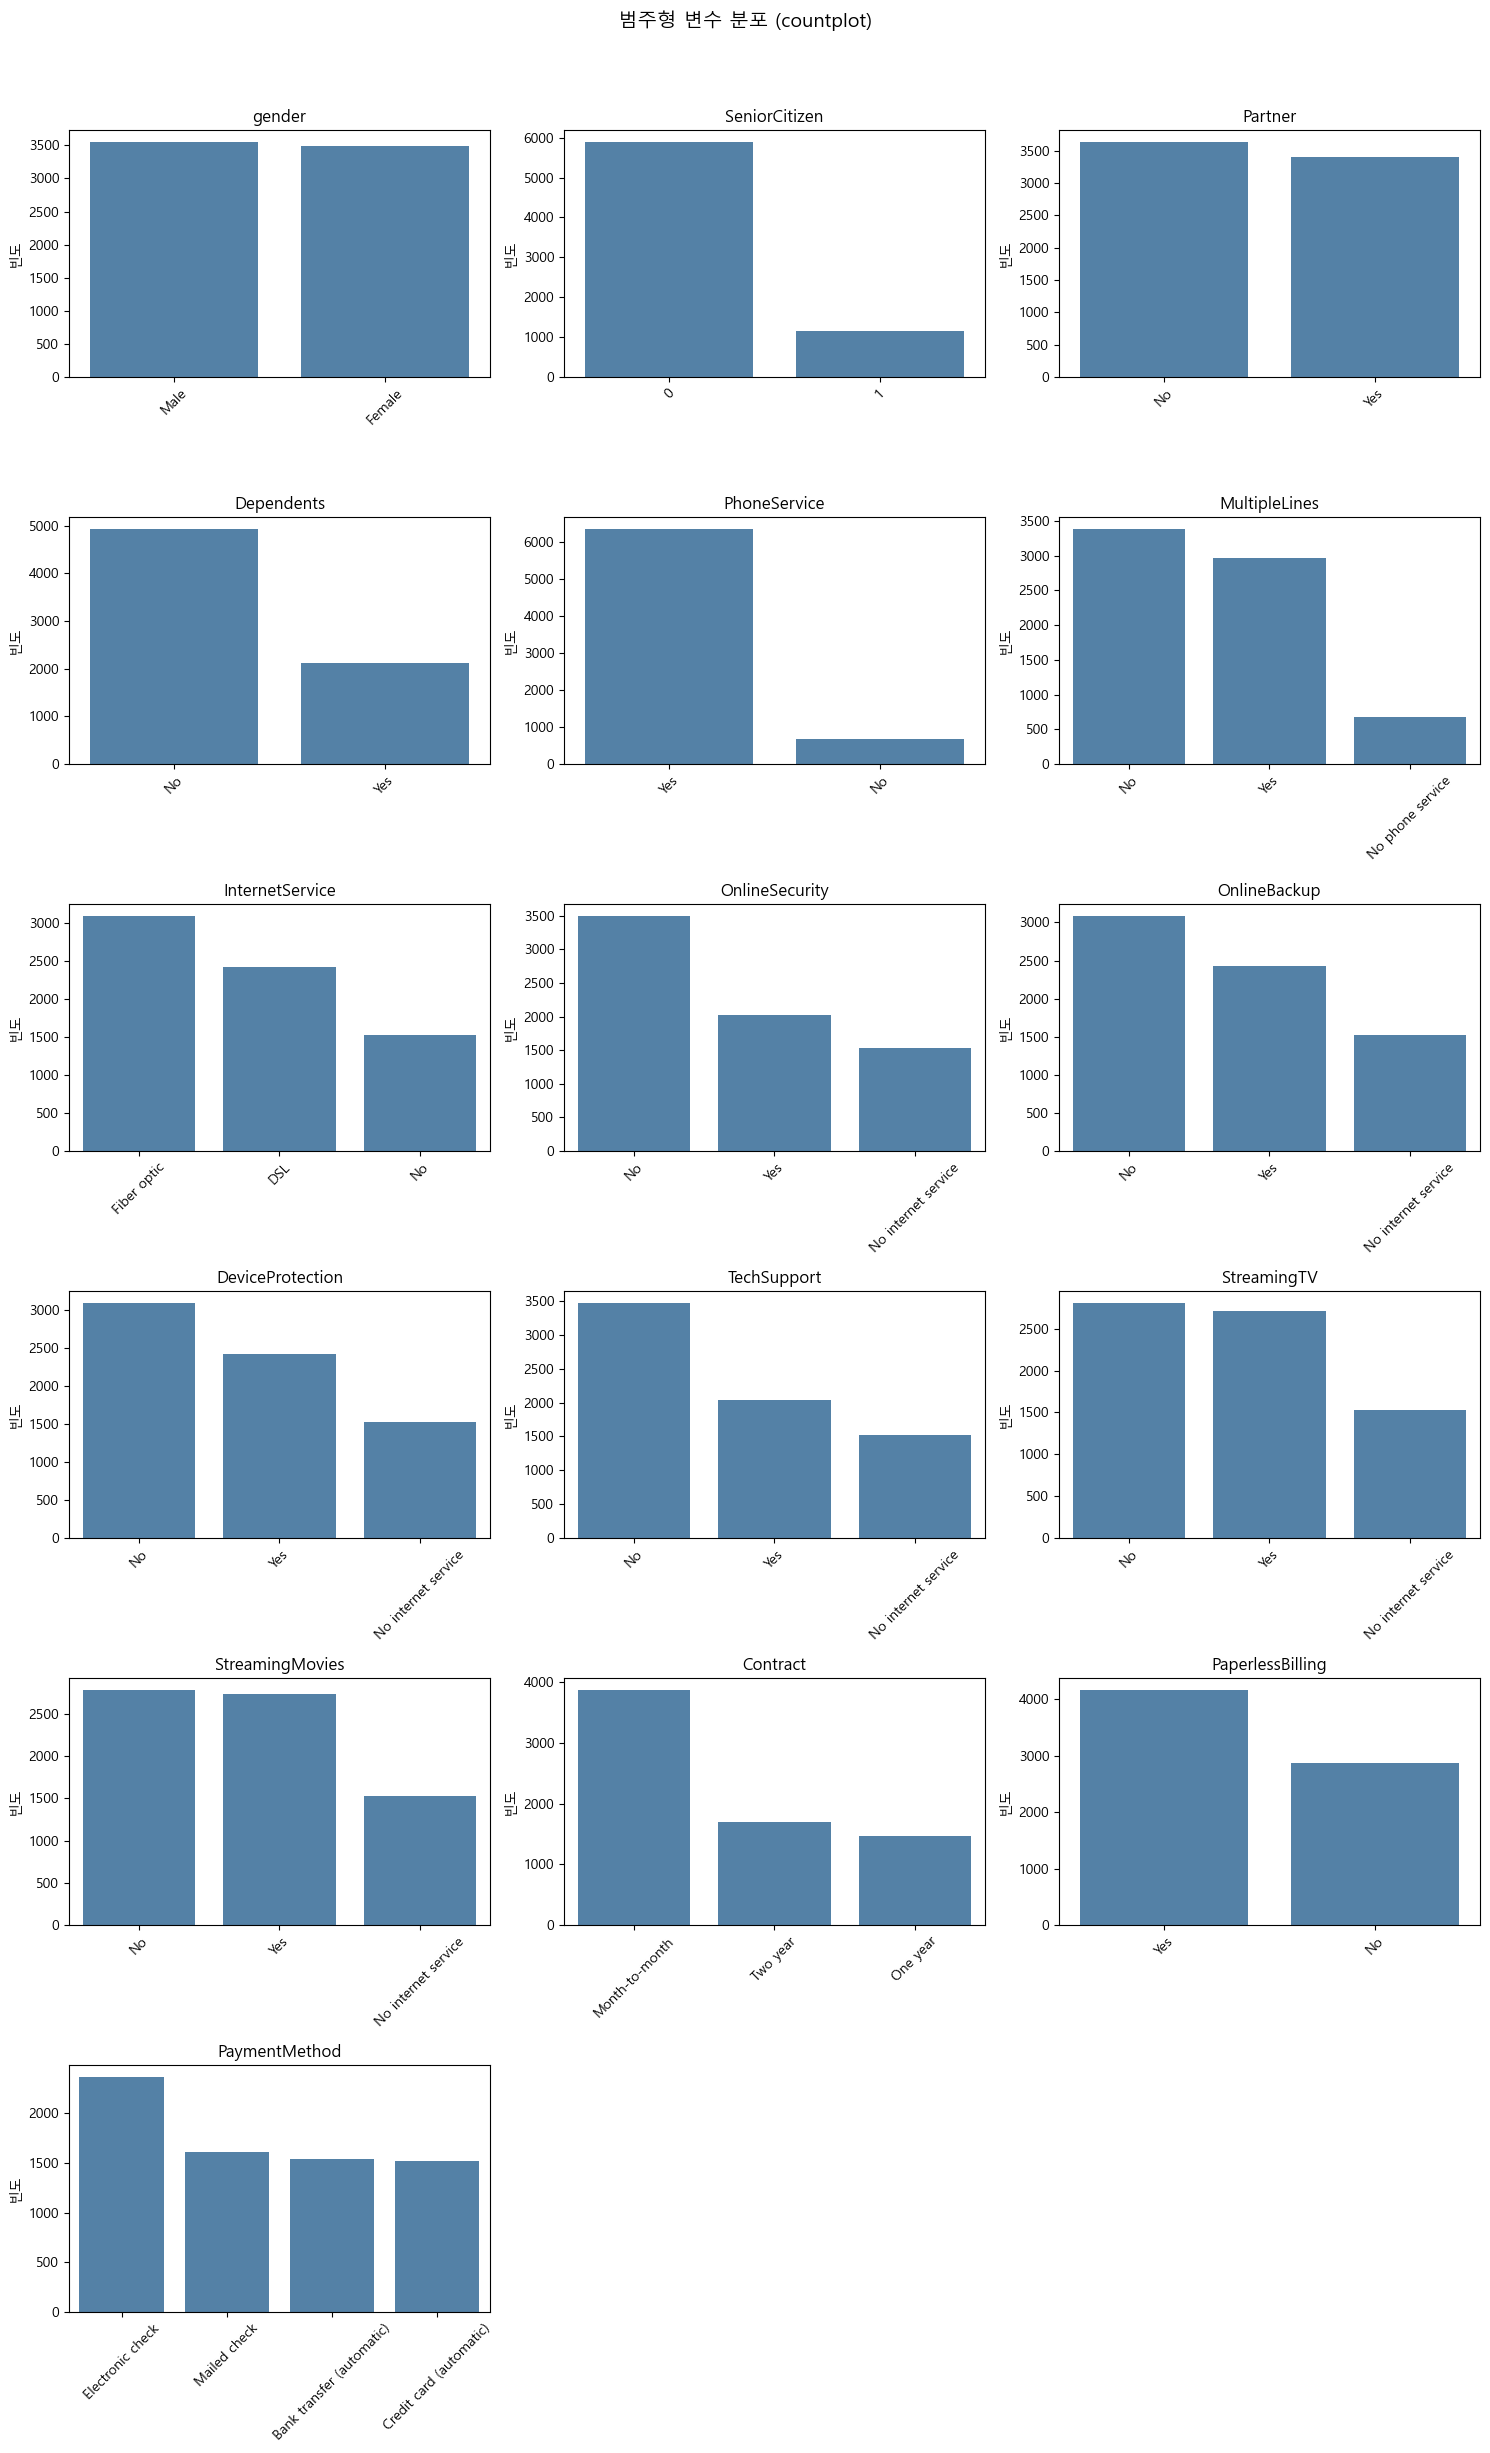

In [8]:
def plot_categorical_distributions(data, cat_columns, title="범주형 변수 분포"):
    """범주형 변수별 countplot"""
    n_cols = 3
    n_rows = -(-len(cat_columns) // n_cols)  # 올림 나누기

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, cat_columns):
        order = data[col].value_counts().index
        sns.countplot(data=data, x=col, order=order, ax=ax, color="steelblue")
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("빈도")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(cat_columns):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# 전체 범주형 변수 분포
plot_categorical_distributions(df_eda, cat_cols, "범주형 변수 분포 (countplot)")

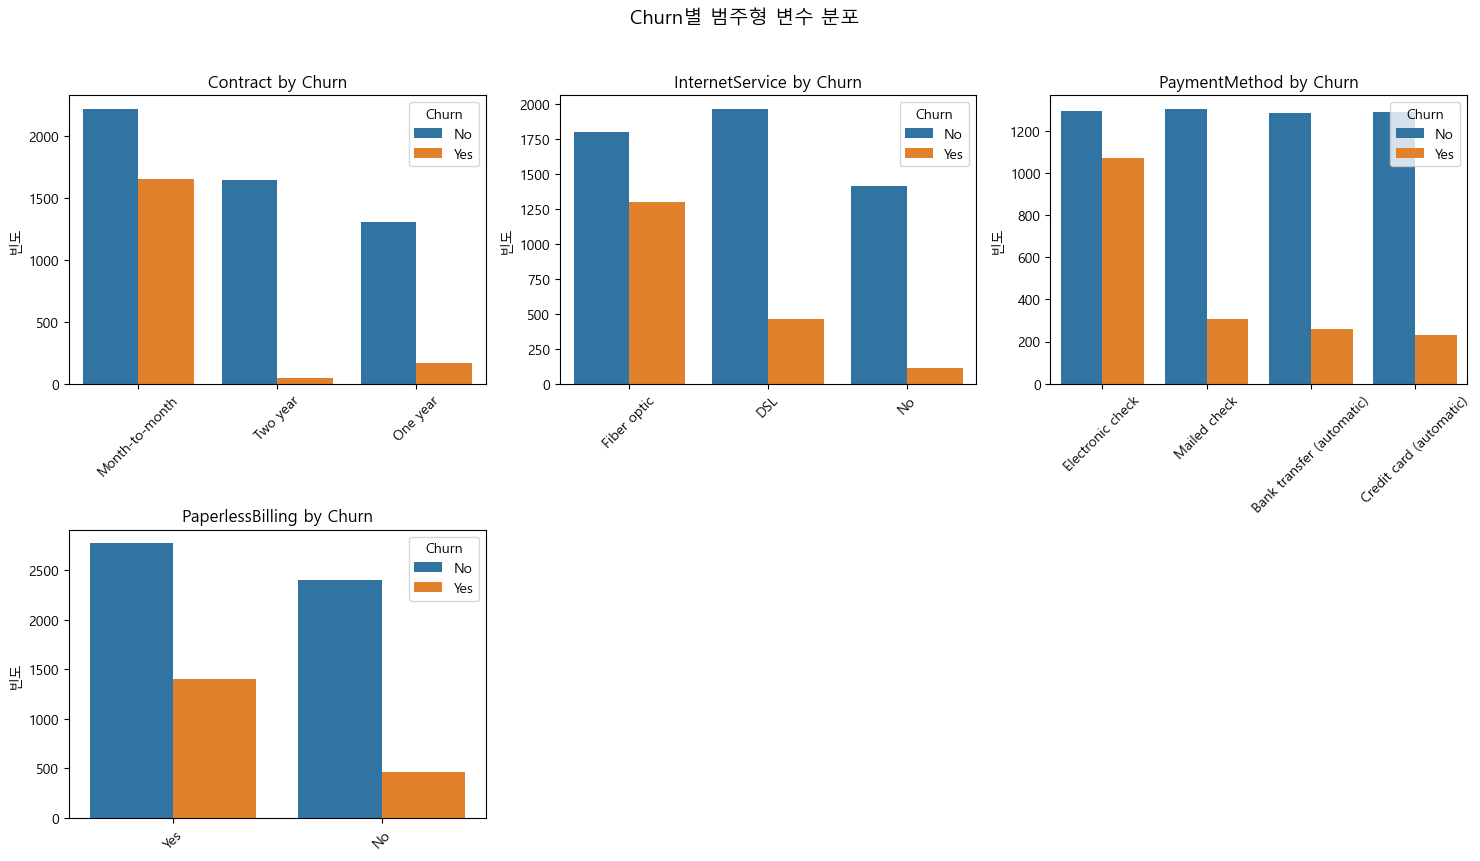

In [10]:
def plot_categorical_by_churn(data, cat_columns, target=TARGET):
    """Churn 여부에 따른 범주형 변수 분포 비교"""
    n_cols = 3
    n_rows = -(-len(cat_columns) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.2 * n_rows))
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, cat_columns):
        sns.countplot(
            data=data, x=col, hue=target,
            order=data[col].value_counts().index,
            hue_order=["No", "Yes"],
            ax=ax
        )
        ax.set_title(f"{col} by {target}")
        ax.set_xlabel("")
        ax.set_ylabel("빈도")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title=target, loc="upper right")

    for ax in axes[len(cat_columns):]:
        ax.axis("off")

    fig.suptitle(f"{target}별 범주형 변수 분포", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# 주요 범주형만 먼저 보고 싶다면
key_cat_cols = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]
plot_categorical_by_churn(df_eda, key_cat_cols)

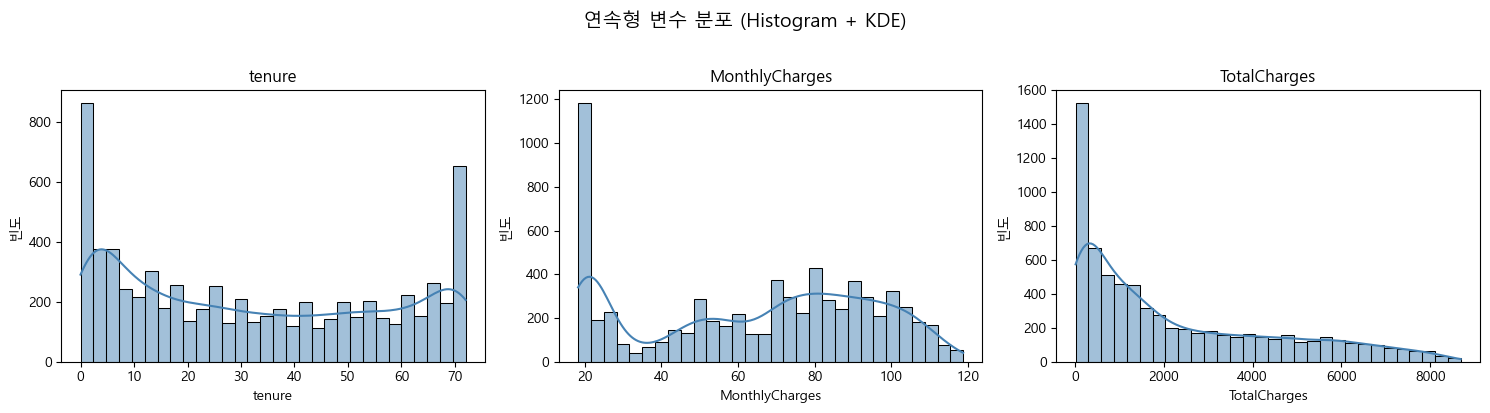

In [9]:
def plot_numeric_distributions(data, num_columns, title="연속형 변수 분포"):
    """연속형 변수별 히스토그램"""
    n_cols = 3
    n_rows = -(-len(num_columns) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, num_columns):
        sns.histplot(data=data, x=col, bins=30, kde=True, ax=ax, color="steelblue")
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("빈도")

    for ax in axes[len(num_columns):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# 전체 연속형 변수 분포
plot_numeric_distributions(df_eda, num_cols, "연속형 변수 분포 (Histogram + KDE)")

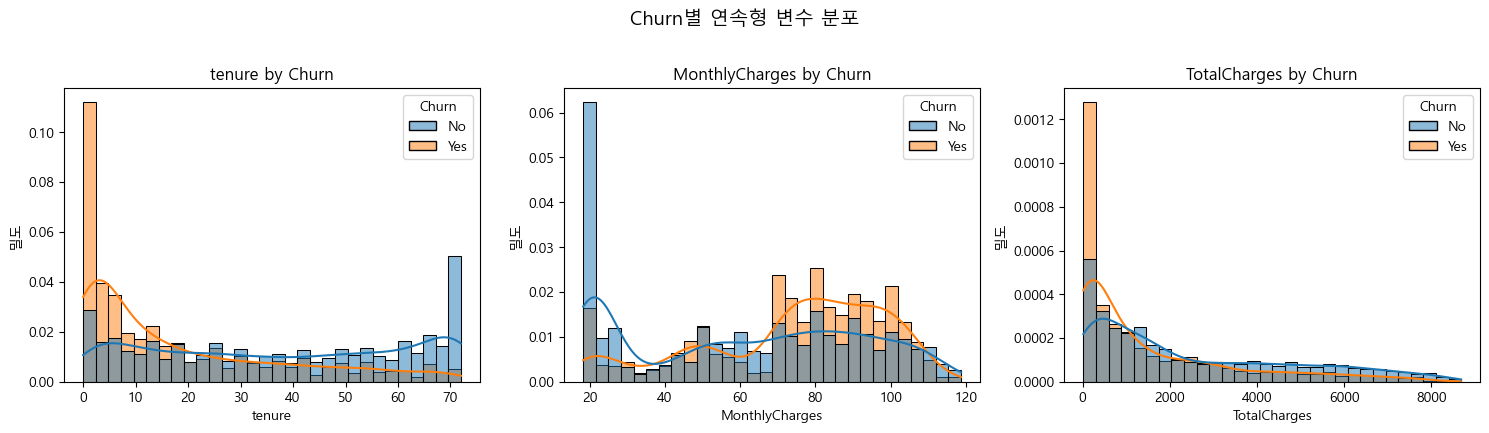

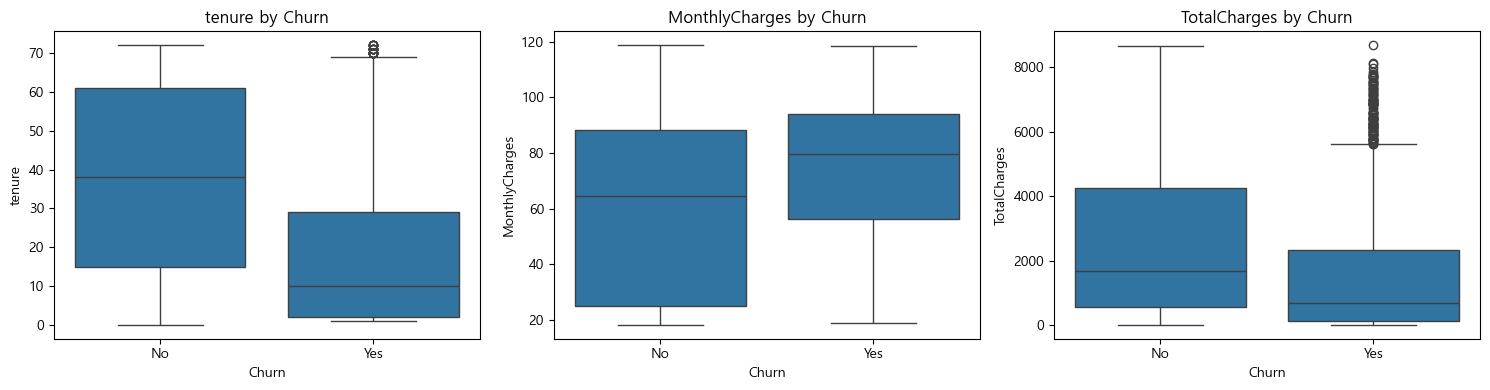

In [11]:
def plot_numeric_by_churn(data, num_columns, target=TARGET):
    """Churn 여부에 따른 연속형 변수 분포 비교"""
    # 1) 히스토그램 (밀도 비교)
    n_cols = 3
    n_rows = -(-len(num_columns) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.2 * n_rows))
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, num_columns):
        sns.histplot(
            data=data, x=col, hue=target,
            bins=30, stat="density",
            common_norm=False, kde=True,
            hue_order=["No", "Yes"],
            ax=ax
        )
        ax.set_title(f"{col} by {target}")
        ax.set_xlabel(col)
        ax.set_ylabel("밀도")

    for ax in axes[len(num_columns):]:
        ax.axis("off")

    fig.suptitle(f"{target}별 연속형 변수 분포", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    # 2) 박스플롯 (분포 요약)
    fig, axes = plt.subplots(1, len(num_columns), figsize=(5 * len(num_columns), 4))
    if len(num_columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, num_columns):
        sns.boxplot(data=data, x=target, y=col, order=["No", "Yes"], ax=ax)
        ax.set_title(f"{col} by {target}")
        ax.set_xlabel(target)
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

plot_numeric_by_churn(df_eda, num_cols)

---

## 2) 데이터 전처리

1. 불필요한 변수 제거
2. 다중공선성 해결
3. 결측치 처리
4. 이상치 처리
5. 클래스 불균형 문제 해결
6. 스케일링/인코딩
7. 변수 내 데이터 값을 적절한 값으로 변경 (ex. "Yes" -> 1)

**[과제]** 써니는 EDA 결과를 바탕으로 모델링에 필요한 전처리 과정을 계획하고자 합니다.

AI와 상의하여 필요한 전처리 항목을 나열한 뒤, 학습 데이터와 테스트 데이터 분할 시점을 고려하여 분할 전에 수행해야 하는 전처리와 분할 후에 수행해야 하는 전처리를 구분해 보세요. 

이후 올바른 순서에 따라 전처리를 진행해 보세요.

In [13]:
TARGET = "Churn"
ID_COLS = ["customerID"]
RANDOM_STATE = 42

# 원본 보존
df_raw = df_eda.copy() if "df_eda" in globals() else df.copy()
df_prep = df_raw.copy()

# TotalCharges 숫자형 변환
df_prep["TotalCharges"] = pd.to_numeric(df_prep["TotalCharges"], errors="coerce")

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in df_prep.columns if c not in ID_COLS + [TARGET] + num_cols]

In [14]:
print("=== [1] 불필요한 변수 제거 ===")
print(f"제거 전 shape: {df_prep.shape}")

# 식별자 제거
drop_cols = [c for c in ID_COLS if c in df_prep.columns]
df_prep = df_prep.drop(columns=drop_cols)

print(f"제거 컬럼: {drop_cols}")
print(f"제거 후 shape: {df_prep.shape}")
print(f"남은 컬럼: {df_prep.columns.tolist()}")

=== [1] 불필요한 변수 제거 ===
제거 전 shape: (7043, 20)
제거 컬럼: []
제거 후 shape: (7043, 20)
남은 컬럼: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



=== [2] 다중공선성 확인 ===


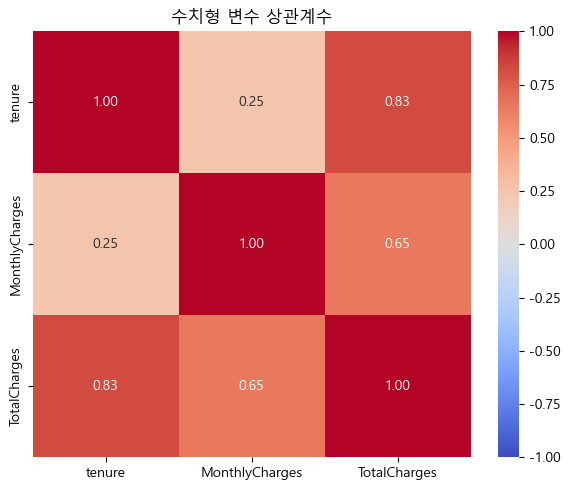

  - tenure <-> TotalCharges: r=0.826
  -> 'TotalCharges' 제거 (타겟 상관 낮음)
다중공선성으로 제거된 변수: ['TotalCharges']


In [15]:
print("\n=== [2] 다중공선성 확인 ===")

# 2-1) 수치형 상관계수 히트맵
corr_mat = df_prep[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("수치형 변수 상관계수")
plt.tight_layout()
plt.show()

# 2-2) 높은 상관쌍 탐색 (|r| >= 0.8)
CORR_THRESHOLD = 0.8
high_corr_pairs = []

for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        r = corr_mat.iloc[i, j]
        if abs(r) >= CORR_THRESHOLD:
            high_corr_pairs.append((num_cols[i], num_cols[j], r))
            print(f"  - {num_cols[i]} <-> {num_cols[j]}: r={r:.3f}")

# 2-3) 타겟과 상관이 낮은 변수 제거
# Churn을 임시 숫자로 변환해 비교
tmp = df_prep.copy()
tmp[TARGET] = tmp[TARGET].map({"No": 0, "Yes": 1})
target_corr = tmp[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs()

cols_to_drop_mc = set()
for v1, v2, r in high_corr_pairs:
    drop_col = v1 if target_corr[v1] < target_corr[v2] else v2
    cols_to_drop_mc.add(drop_col)
    print(f"  -> '{drop_col}' 제거 (타겟 상관 낮음)")

if cols_to_drop_mc:
    df_prep = df_prep.drop(columns=list(cols_to_drop_mc))
    num_cols = [c for c in num_cols if c not in cols_to_drop_mc]
    print(f"다중공선성으로 제거된 변수: {list(cols_to_drop_mc)}")
else:
    print("제거할 다중공선성 변수 없음")

In [16]:
print("\n=== [3] 결측치 처리 ===")

print("처리 전 결측치:")
missing_before = df_prep.isnull().sum()
print(missing_before[missing_before > 0] if missing_before.sum() > 0 else "결측치 없음")

# 현재 남아 있는 수치형 / 범주형 컬럼만 사용 (TotalCharges 제외)
num_cols_current = [c for c in num_cols if c in df_prep.columns]
cat_cols_current = [c for c in cat_cols if c in df_prep.columns]

# 범주형: 최빈값 대치
for col in cat_cols_current:
    n_miss = df_prep[col].isnull().sum()
    if n_miss > 0:
        mode_val = df_prep[col].mode()[0]
        df_prep[col] = df_prep[col].fillna(mode_val)
        print(f"[{col}] 최빈값 '{mode_val}' 대치 → {n_miss}개")

# 수치형: 중앙값 대치
for col in num_cols_current:
    n_miss = df_prep[col].isnull().sum()
    if n_miss > 0:
        med = df_prep[col].median()
        df_prep[col] = df_prep[col].fillna(med)
        print(f"[{col}] 중앙값 {med} 대치 → {n_miss}개")

print("\n처리 후 결측치:")
missing_after = df_prep.isnull().sum()
if missing_after.sum() == 0:
    print("결측치 0개")
else:
    print(missing_after[missing_after > 0])


=== [3] 결측치 처리 ===
처리 전 결측치:
결측치 없음

처리 후 결측치:
결측치 0개


In [17]:
print("\n=== [4] 이상치 처리 ===")

def get_iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def evaluate_outlier_risk(data, cols, target=TARGET):
    results = []
    outlier_mask_all = pd.Series(False, index=data.index)

    for col in cols:
        if col not in data.columns:
            continue
        lower, upper = get_iqr_bounds(data[col])
        mask = (data[col] < lower) | (data[col] > upper)
        outlier_mask_all |= mask

        removed = data[mask]
        yes_in_removed = (removed[target] == "Yes").sum()
        total_yes = (data[target] == "Yes").sum()

        results.append({
            "변수": col,
            "하한": round(lower, 2),
            "상한": round(upper, 2),
            "이상치 수": mask.sum(),
            "이상치 내 Yes": yes_in_removed,
            "Yes 손실비율(%)": round(yes_in_removed / total_yes * 100, 2) if total_yes > 0 else 0
        })

    return pd.DataFrame(results), outlier_mask_all

outlier_summary, outlier_mask = evaluate_outlier_risk(df_prep, num_cols)
display(outlier_summary)

# Churn 데이터는 이상치 제거 시 소수 클래스 손실 위험 → 기본은 '제거하지 않음'
REMOVE_OUTLIERS = False   # True로 바꾸면 이상치 행 제거

if REMOVE_OUTLIERS and outlier_mask.sum() > 0:
    before = len(df_prep)
    df_prep = df_prep[~outlier_mask].copy()
    print(f"이상치 {outlier_mask.sum()}행 제거 → {before} → {len(df_prep)}")
else:
    print("이상치 제거하지 않음 (권장)")


=== [4] 이상치 처리 ===


,변수,하한,상한,이상치 수,이상치 내 Yes,Yes 손실비율(%)
0,tenure,-60.00,124.00,0,0,0.0
1,MonthlyCharges,-46.02,171.38,0,0,0.0


이상치 제거하지 않음 (권장)


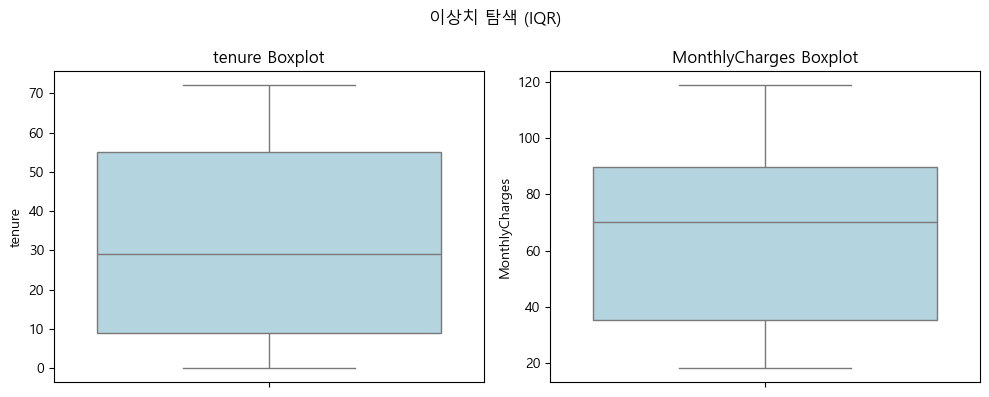

In [18]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    if col not in df_prep.columns:
        continue
    sns.boxplot(y=df_prep[col], ax=ax, color="lightblue")
    ax.set_title(f"{col} Boxplot")

plt.suptitle("이상치 탐색 (IQR)")
plt.tight_layout()
plt.show()


=== Train/Test 분할 ===
X_train: (5634, 18), X_test: (1409, 18)
y_train 분포:
 Churn
0    4139
1    1495
Name: count, dtype: int64
y_test 분포:
 Churn
0    1035
1     374
Name: count, dtype: int64


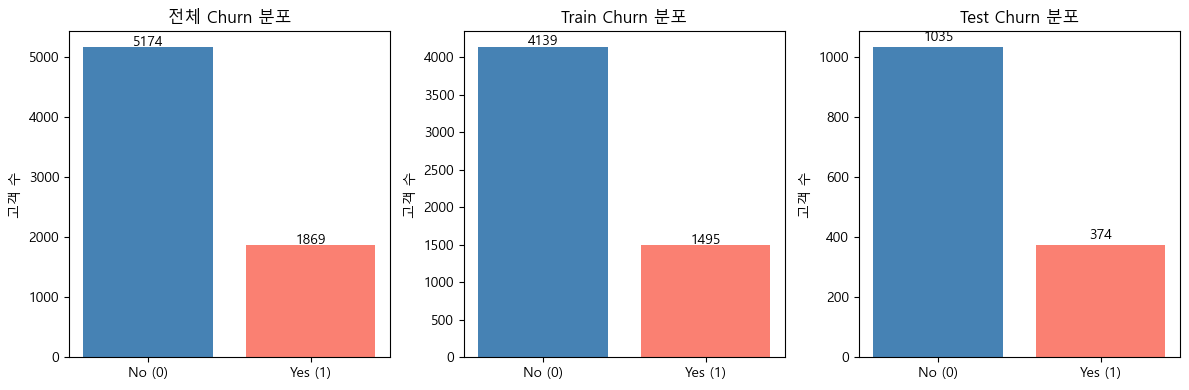

In [19]:
print("\n=== Train/Test 분할 ===")

y = df_prep[TARGET].map({"No": 0, "Yes": 1})
X = df_prep.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("y_train 분포:\n", y_train.value_counts())
print("y_test 분포:\n", y_test.value_counts())

# 클래스 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, title, y_data in zip(axes, ["전체", "Train", "Test"], [y, y_train, y_test]):
    counts = y_data.value_counts().sort_index()
    ax.bar(["No (0)", "Yes (1)"], counts.values, color=["steelblue", "salmon"])
    ax.set_title(f"{title} Churn 분포")
    ax.set_ylabel("고객 수")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.show()

In [20]:
print("\n=== [7] 변수 값 변경 (Label Mapping) ===")

binary_map = {
    "gender": {"Male": 1, "Female": 0},
    "Partner": {"Yes": 1, "No": 0},
    "Dependents": {"Yes": 1, "No": 0},
    "PhoneService": {"Yes": 1, "No": 0},
    "PaperlessBilling": {"Yes": 1, "No": 0},
}

for col, mapping in binary_map.items():
    if col in X_train.columns:
        X_train[col] = X_train[col].map(mapping)
        X_test[col] = X_test[col].map(mapping)
        print(f"[{col}] 매핑 완료: {mapping}")

# SeniorCitizen은 이미 0/1
print("SeniorCitizen 고유값:", X_train["SeniorCitizen"].unique())


=== [7] 변수 값 변경 (Label Mapping) ===
[gender] 매핑 완료: {'Male': 1, 'Female': 0}
[Partner] 매핑 완료: {'Yes': 1, 'No': 0}
[Dependents] 매핑 완료: {'Yes': 1, 'No': 0}
[PhoneService] 매핑 완료: {'Yes': 1, 'No': 0}
[PaperlessBilling] 매핑 완료: {'Yes': 1, 'No': 0}
SeniorCitizen 고유값: [0 1]



=== [6] 인코딩 + 스케일링 ===
인코딩 전 feature 수: 18
인코딩 후 feature 수: 39

스케일링 완료
X_train_scaled: (5634, 39)
X_test_scaled: (1409, 39)


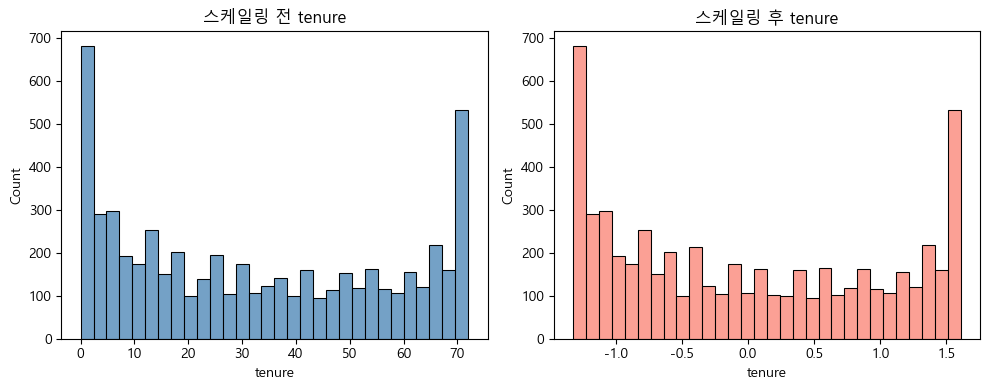

In [21]:
print("\n=== [6] 인코딩 + 스케일링 ===")

# One-Hot Encoding 대상 (다중 범주형)
ohe_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod",
]
ohe_cols = [c for c in ohe_cols if c in X_train.columns]

X_train_enc = pd.get_dummies(X_train, columns=ohe_cols, drop_first=False)
X_test_enc = pd.get_dummies(X_test, columns=ohe_cols, drop_first=False)

# train/test 컬럼 맞추기
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"인코딩 전 feature 수: {X_train.shape[1]}")
print(f"인코딩 후 feature 수: {X_train_enc.shape[1]}")

# StandardScaler (연속형만)
scale_cols = [c for c in num_cols if c in X_train_enc.columns]

scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_enc[scale_cols])

print(f"\n스케일링 완료")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

# 스케일링 전후 비교 (tenure 예시)
if "tenure" in scale_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(X_train_enc["tenure"], bins=30, ax=axes[0], color="steelblue")
    axes[0].set_title("스케일링 전 tenure")
    sns.histplot(X_train_scaled["tenure"], bins=30, ax=axes[1], color="salmon")
    axes[1].set_title("스케일링 후 tenure")
    plt.tight_layout()
    plt.show()

In [22]:
print("\n=== [5] 클래스 불균형 처리 (Train only) ===")

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks

# 기본 학습용 (불균형 유지)
X_train_base, y_train_base = X_train_scaled.copy(), y_train.copy()

# Resampling 적용 (train만!)
X_train_smote, y_train_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(
    X_train_scaled, y_train
)
X_train_tl, y_train_tl = TomekLinks().fit_resample(
    X_train_scaled, y_train
)
X_train_st, y_train_st = SMOTETomek(random_state=RANDOM_STATE).fit_resample(
    X_train_scaled, y_train
)

# 분포 비교표
compare_imbalance = pd.DataFrame({
    "원본 Train": y_train.value_counts().sort_index(),
    "SMOTE": pd.Series(y_train_smote).value_counts().sort_index(),
    "TomekLinks": pd.Series(y_train_tl).value_counts().sort_index(),
    "SMOTE+Tomek": pd.Series(y_train_st).value_counts().sort_index(),
})
display(compare_imbalance)


=== [5] 클래스 불균형 처리 (Train only) ===


,원본 Train,SMOTE,TomekLinks,SMOTE+Tomek
Churn,,,,
0,4139,4139,3756,3958
1,1495,4139,1495,3958


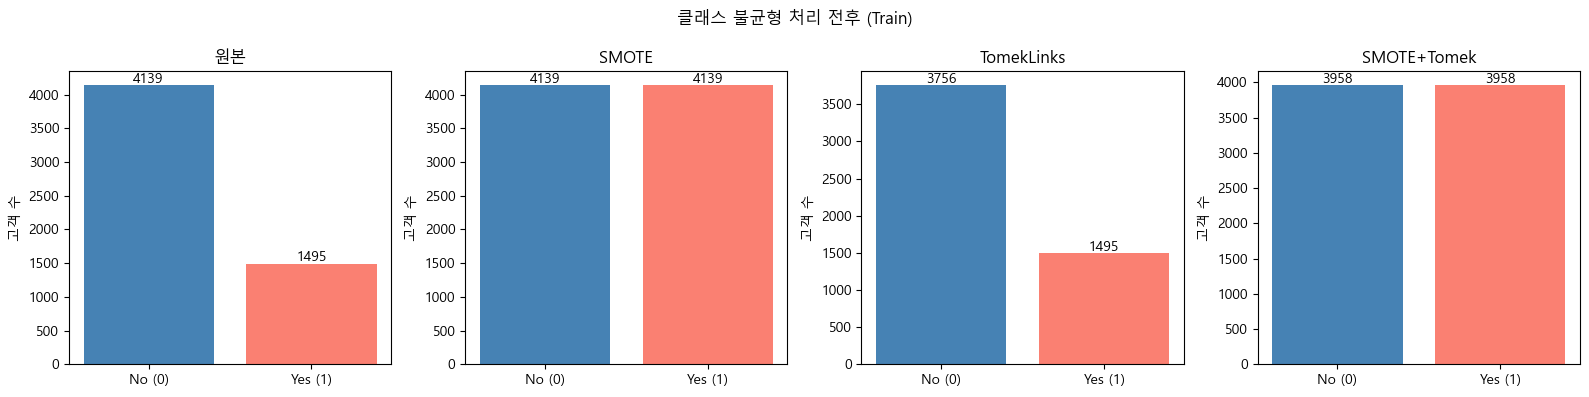

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
datasets = [
    ("원본", y_train),
    ("SMOTE", y_train_smote),
    ("TomekLinks", y_train_tl),
    ("SMOTE+Tomek", y_train_st),
]

for ax, (name, y_data) in zip(axes, datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    ax.bar(["No (0)", "Yes (1)"], counts.values, color=["steelblue", "salmon"])
    ax.set_title(name)
    ax.set_ylabel("고객 수")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha="center")

plt.suptitle("클래스 불균형 처리 전후 (Train)")
plt.tight_layout()
plt.show()

In [24]:
# 모델링에 바로 쓸 수 있도록 dict로 정리
preprocessed = {
    "base": (X_train_base, X_test_scaled, y_train_base, y_test),
    "smote": (X_train_smote, X_test_scaled, y_train_smote, y_test),
    "tomek": (X_train_tl, X_test_scaled, y_train_tl, y_test),
    "smote_tomek": (X_train_st, X_test_scaled, y_train_st, y_test),
}

print("\n=== 전처리 완료 ===")
for name, (Xtr, Xte, ytr, yte) in preprocessed.items():
    print(f"[{name}] X_train: {Xtr.shape}, X_test: {Xte.shape}, "
          f"y_train Yes비율: {(ytr==1).mean()*100:.1f}%")


=== 전처리 완료 ===
[base] X_train: (5634, 39), X_test: (1409, 39), y_train Yes비율: 26.5%
[smote] X_train: (8278, 39), X_test: (1409, 39), y_train Yes비율: 50.0%
[tomek] X_train: (5251, 39), X_test: (1409, 39), y_train Yes비율: 28.5%
[smote_tomek] X_train: (7916, 39), X_test: (1409, 39), y_train Yes비율: 50.0%


---

## 3) 모델링 및 모델 고도화

1. 단일 모델 (Logistic Regression, Decision Tree)
2. 앙상블 모델 (Random Forest, GBM, XGBoost, LightGBM, CatBoost)

**[과제]** 써니는 본 데이터에 가장 적합한 분류 모델이 무엇인지 알아보고자 합니다.

AI와 상의하여 다양한 분류 모델을 선정하고 학습시키는 코드를 작성한 뒤, Accuracy, Precision, Recall, F1-score, AUC-ROC 등의 분류 평가 지표를 활용하여 모델별 성능을 비교해 보세요.

In [25]:
# 전처리 결과가 preprocessed dict에 있다면
X_train_use, X_test_use, y_train_use, y_test_use = preprocessed["base"]
# 또는 SMOTE 적용 데이터를 쓰려면:
# X_train_use, X_test_use, y_train_use, y_test_use = preprocessed["smote"]

RANDOM_STATE = 42
POS_LABEL = 1   # Yes(이탈) = 1

In [26]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

def evaluate_classifier(model, X_train, y_train, X_test, y_test,
                        model_name="Model", verbose=True):
    """
    분류 모델 학습 + 평가
    반환: metrics dict, fitted model, y_pred, y_proba
    """
    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # predict_proba 지원 모델만 AUC 계산
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = None

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "Train_Time(sec)": round(time.time() - start, 3),
    }

    if verbose:
        print(f"\n[{model_name}]")
        for k, v in metrics.items():
            if k == "Model":
                continue
            if isinstance(v, float):
                print(f"  {k:16s}: {v:.4f}")
            else:
                print(f"  {k:16s}: {v}")

        print("\n  Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        print("\n  Classification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=["No(0)", "Yes(1)"],
            zero_division=0
        ))

    return {
        "metrics": metrics,
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


def results_to_dataframe(result_list):
    """여러 모델 평가 결과를 DataFrame으로 변환"""
    df = pd.DataFrame([r["metrics"] for r in result_list])
    return df.sort_values("F1-score", ascending=False).reset_index(drop=True)


def plot_model_comparison(results_df, metric="F1-score"):
    """모델별 성능 막대그래프"""
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_df, x="Model", y=metric, hue="Model", palette="Set2", legend=False)
    plt.title(f"모델별 {metric} 비교")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


def plot_roc_curves(result_list, y_test):
    """ROC 곡선 비교"""
    plt.figure(figsize=(8, 6))

    for res in result_list:
        if res["y_proba"] is not None:
            RocCurveDisplay.from_predictions(
                y_test, res["y_proba"],
                name=res["metrics"]["Model"],
                ax=plt.gca()
            )

    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.title("ROC Curve 비교")
    plt.legend()
    plt.tight_layout()
    plt.show()

단일 모델 평가

[Logistic Regression]
  Accuracy        : 0.7395
  Precision       : 0.5061
  Recall          : 0.7754
  F1-score        : 0.6125
  AUC-ROC         : 0.8385
  Train_Time(sec) : 0.0430

  Confusion Matrix:
[[752 283]
 [ 84 290]]

  Classification Report:
              precision    recall  f1-score   support

       No(0)       0.90      0.73      0.80      1035
      Yes(1)       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


[Decision Tree]
  Accuracy        : 0.7395
  Precision       : 0.5058
  Recall          : 0.8128
  F1-score        : 0.6236
  AUC-ROC         : 0.8343
  Train_Time(sec) : 0.0310

  Confusion Matrix:
[[738 297]
 [ 70 304]]

  Classification Report:
              precision    recall  f1-score   support

       No(0)       0.91      0.71      0.80      1035
      Yes(1)       0.51      0.81      0.62       3

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC,Train_Time(sec)
0,Decision Tree,0.7395,0.5058,0.8128,0.6236,0.8343,0.031
1,Logistic Regression,0.7395,0.5061,0.7754,0.6125,0.8385,0.043


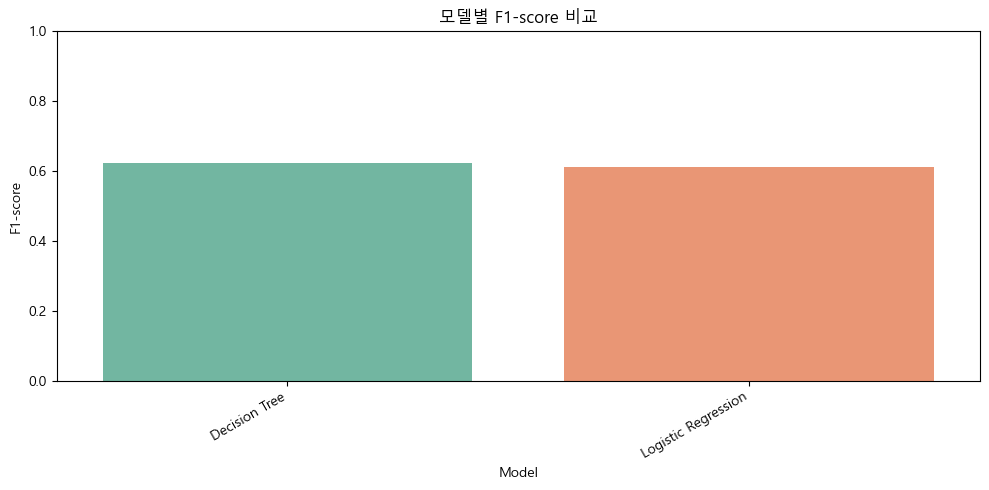

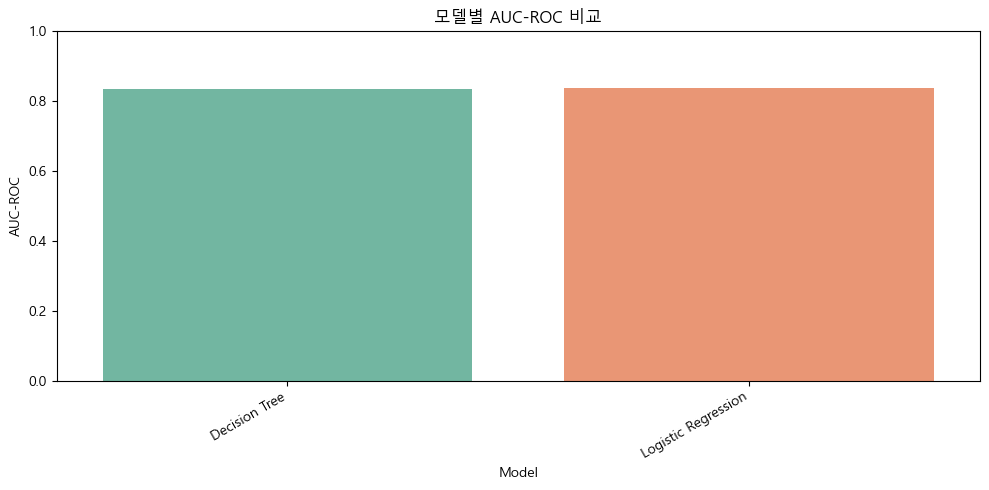

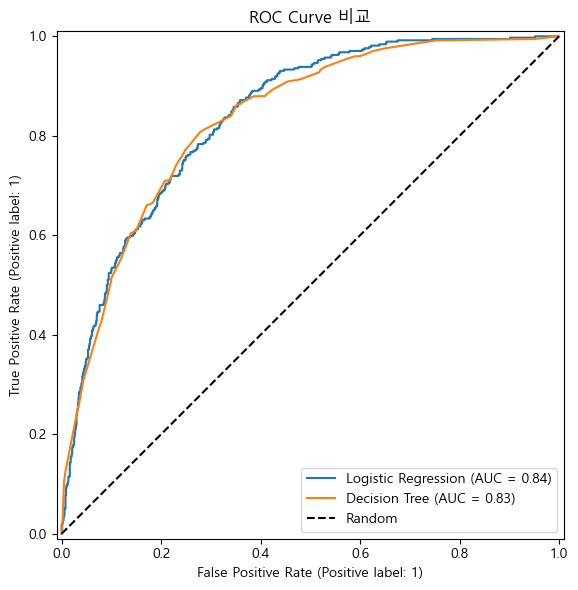

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 클래스 불균형 반영 (base 데이터 사용 시)
scale_pos_weight = (y_train_use == 0).sum() / (y_train_use == 1).sum()

single_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
}

single_results = []
fitted_single_models = {}

print("=" * 60)
print("단일 모델 평가")
print("=" * 60)

for name, model in single_models.items():
    result = evaluate_classifier(
        model,
        X_train_use, y_train_use,
        X_test_use, y_test_use,
        model_name=name,
        verbose=True
    )
    single_results.append(result)
    fitted_single_models[name] = result["model"]

single_df = results_to_dataframe(single_results)
print("\n=== 단일 모델 성능 비교 ===")
display(single_df.round(4))

plot_model_comparison(single_df, metric="F1-score")
plot_model_comparison(single_df, metric="AUC-ROC")
plot_roc_curves(single_results, y_test_use)

앙상블 모델 평가

[Random Forest]
  Accuracy        : 0.7559
  Precision       : 0.5278
  Recall          : 0.7620
  F1-score        : 0.6236
  AUC-ROC         : 0.8379
  Train_Time(sec) : 0.5760

  Confusion Matrix:
[[780 255]
 [ 89 285]]

  Classification Report:
              precision    recall  f1-score   support

       No(0)       0.90      0.75      0.82      1035
      Yes(1)       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


[GBM]
  Accuracy        : 0.8027
  Precision       : 0.6633
  Recall          : 0.5214
  F1-score        : 0.5838
  AUC-ROC         : 0.8360
  Train_Time(sec) : 3.1180

  Confusion Matrix:
[[936  99]
 [179 195]]

  Classification Report:
              precision    recall  f1-score   support

       No(0)       0.84      0.90      0.87      1035
      Yes(1)       0.66      0.52      0.58       374

    accurac

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC,Train_Time(sec)
0,CatBoost,0.7523,0.5220,0.7941,0.6299,0.8419,1.207
1,Random Forest,0.7559,0.5278,0.7620,0.6236,0.8379,0.576
2,LightGBM,0.7523,0.5232,0.7540,0.6177,0.8348,0.184
3,XGBoost,0.7431,0.5111,0.7406,0.6048,0.8313,0.569
4,GBM,0.8027,0.6633,0.5214,0.5838,0.8360,3.118


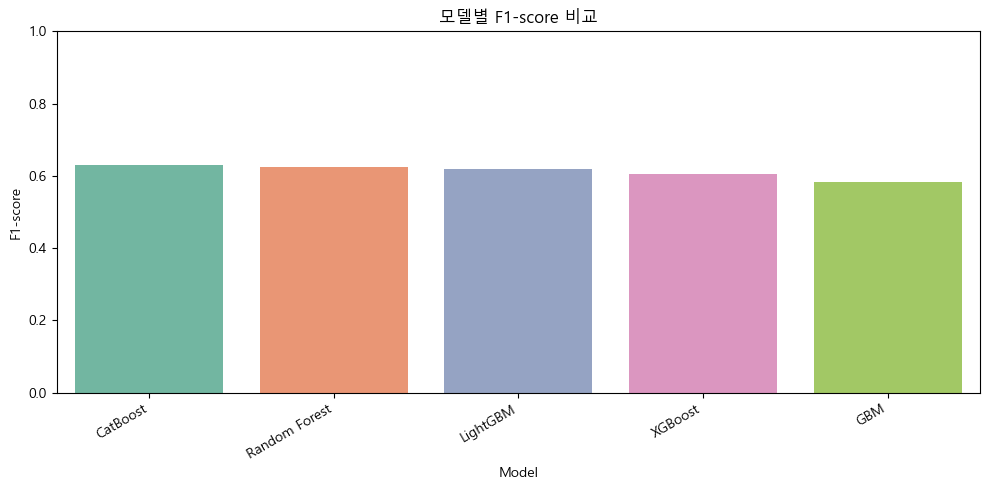

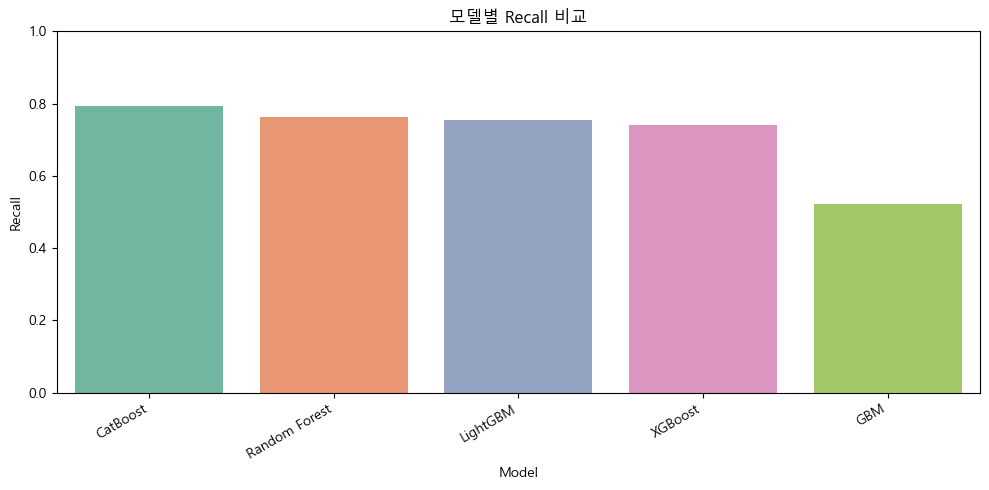

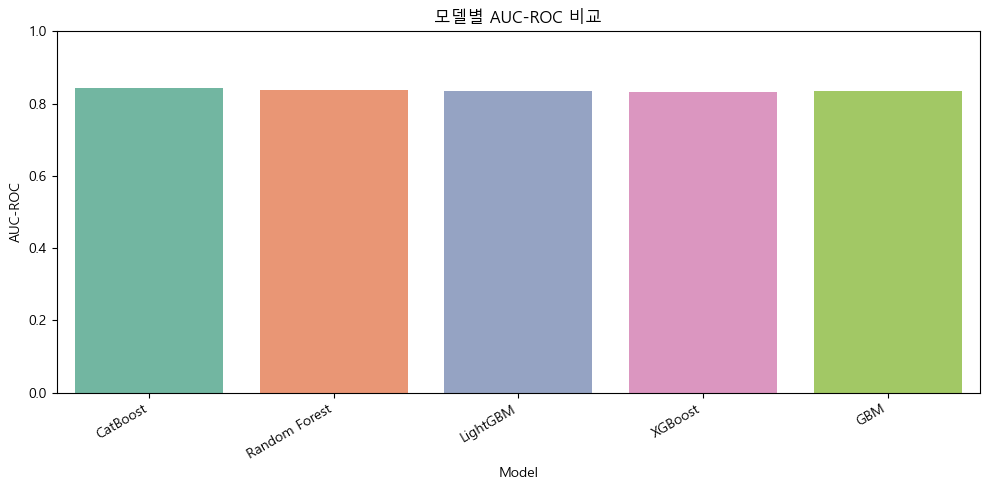

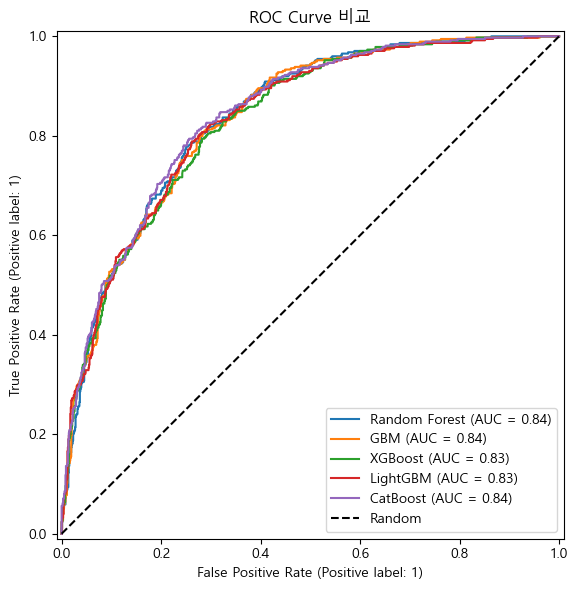

In [28]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

ensemble_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GBM": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        auto_class_weights="Balanced",
        random_state=RANDOM_STATE,
        verbose=0
    ),
}

ensemble_results = []
fitted_ensemble_models = {}

print("=" * 60)
print("앙상블 모델 평가")
print("=" * 60)

for name, model in ensemble_models.items():
    result = evaluate_classifier(
        model,
        X_train_use, y_train_use,
        X_test_use, y_test_use,
        model_name=name,
        verbose=True
    )
    ensemble_results.append(result)
    fitted_ensemble_models[name] = result["model"]

ensemble_df = results_to_dataframe(ensemble_results)
print("\n=== 앙상블 모델 성능 비교 ===")
display(ensemble_df.round(4))

plot_model_comparison(ensemble_df, metric="F1-score")
plot_model_comparison(ensemble_df, metric="Recall")
plot_model_comparison(ensemble_df, metric="AUC-ROC")
plot_roc_curves(ensemble_results, y_test_use)

=== 전체 모델 성능 순위 (F1-score 기준) ===


,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC,Train_Time(sec)
0,CatBoost,0.7523,0.5220,0.7941,0.6299,0.8419,1.207
1,Random Forest,0.7559,0.5278,0.7620,0.6236,0.8379,0.576
2,Decision Tree,0.7395,0.5058,0.8128,0.6236,0.8343,0.031
3,LightGBM,0.7523,0.5232,0.7540,0.6177,0.8348,0.184
4,Logistic Regression,0.7395,0.5061,0.7754,0.6125,0.8385,0.043
5,XGBoost,0.7431,0.5111,0.7406,0.6048,0.8313,0.569
6,GBM,0.8027,0.6633,0.5214,0.5838,0.8360,3.118


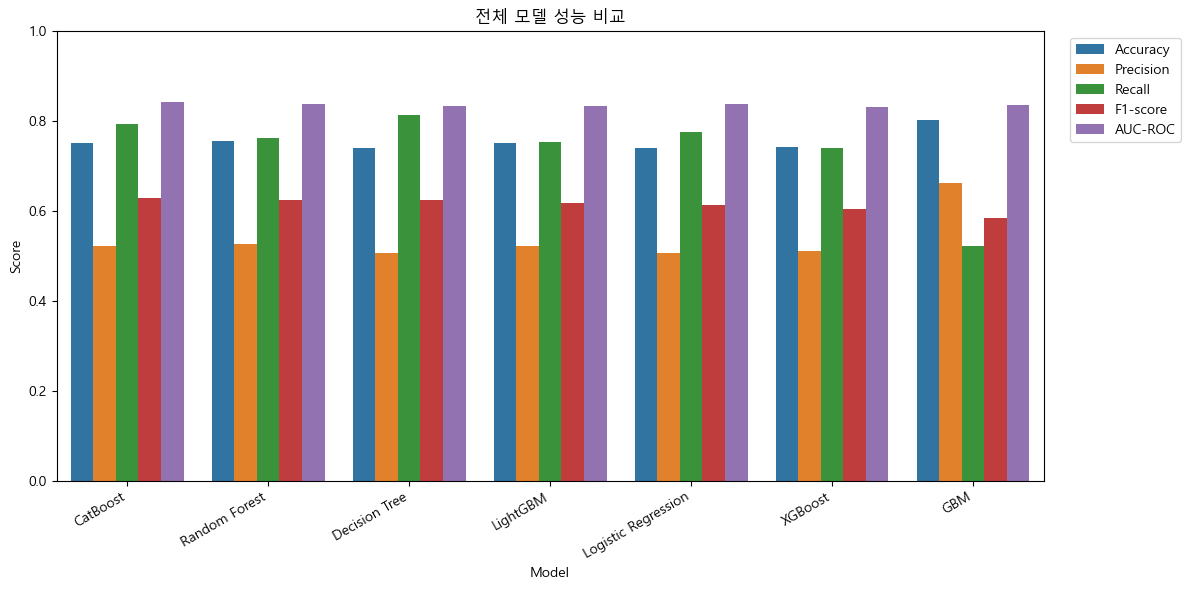


최고 F1-score 모델: CatBoost


In [29]:
all_results = single_results + ensemble_results
all_df = results_to_dataframe(all_results)

print("=== 전체 모델 성능 순위 (F1-score 기준) ===")
display(all_df.round(4))

# 핵심 지표 한눈에 보기
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]
all_df_melt = all_df.melt(
    id_vars="Model", value_vars=metric_cols,
    var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=all_df_melt, x="Model", y="Score", hue="Metric")
plt.title("전체 모델 성능 비교")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 최고 모델
best_model_name = all_df.loc[0, "Model"]
best_model = fitted_single_models.get(best_model_name) or fitted_ensemble_models.get(best_model_name)
print(f"\n최고 F1-score 모델: {best_model_name}")

**[과제]** 써니는 모델의 성능을 더욱 향상시키고자 합니다.

AI와 상의하여 Grid Search 또는 Random Search를 활용한 하이퍼파라미터 튜닝 코드를 작성하고, 튜닝 전후의 모델 성능을 비교해 보세요.

In [31]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# 전처리 데이터 (이전 셀에서 생성)
X_train_use, X_test_use, y_train_use, y_test_use = preprocessed["base"]
# SMOTE 데이터를 쓰는 경우:
# X_train_use, X_test_use, y_train_use, y_test_use = preprocessed["smote"]

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = "f1"   # Churn 불균형 → F1 기준 튜닝

scale_pos_weight = (y_train_use == 0).sum() / (y_train_use == 1).sum()

In [32]:
def run_grid_search(model, param_grid, model_name, X_train, y_train):
    """GridSearchCV 실행"""
    start = time.time()

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=CV,
        scoring=SCORING,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    grid.fit(X_train, y_train)

    print(f"\n[{model_name}] Grid Search 완료 ({time.time()-start:.1f}s)")
    print(f"  탐색 조합 수 : {len(grid.cv_results_['params'])}")
    print(f"  최적 파라미터: {grid.best_params_}")
    print(f"  최적 CV F1    : {grid.best_score_:.4f}")

    return grid


def run_random_search(model, param_dist, model_name, X_train, y_train, n_iter=30):
    """RandomizedSearchCV 실행"""
    start = time.time()

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=CV,
        scoring=SCORING,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    random_search.fit(X_train, y_train)

    print(f"\n[{model_name}] Random Search 완료 ({time.time()-start:.1f}s)")
    print(f"  탐색 조합 수 : {random_search.n_iter}")
    print(f"  최적 파라미터: {random_search.best_params_}")
    print(f"  최적 CV F1    : {random_search.best_score_:.4f}")

    return random_search


def compare_before_after(baseline_model, tuned_model, model_name,
                         X_train, y_train, X_test, y_test):
    """튜닝 전/후 테스트 성능 비교"""
    base_res = evaluate_classifier(
        baseline_model, X_train, y_train, X_test, y_test,
        model_name=f"{model_name} (기본)", verbose=False
    )
    tuned_res = evaluate_classifier(
        tuned_model, X_train, y_train, X_test, y_test,
        model_name=f"{model_name} (튜닝)", verbose=False
    )

    compare_df = pd.DataFrame([
        base_res["metrics"],
        tuned_res["metrics"]
    ])
    return compare_df, base_res, tuned_res

In [33]:
print("=" * 70)
print("1) Grid Search 하이퍼파라미터 튜닝")
print("=" * 70)

# ----- 1-1) Logistic Regression -----
logit_base = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
)

logit_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
}

grid_logit = run_grid_search(
    logit_base, logit_param_grid, "Logistic Regression",
    X_train_use, y_train_use
)

# ----- 1-2) Decision Tree -----
dt_base = DecisionTreeClassifier(
    class_weight="balanced", random_state=RANDOM_STATE
)

dt_param_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 10, 30],
    "min_samples_leaf": [1, 5, 20],
}

grid_dt = run_grid_search(
    dt_base, dt_param_grid, "Decision Tree",
    X_train_use, y_train_use
)

# ----- 1-3) Random Forest (작은 grid) -----
rf_base = RandomForestClassifier(
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 12, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

grid_rf = run_grid_search(
    rf_base, rf_param_grid, "Random Forest",
    X_train_use, y_train_use
)

1) Grid Search 하이퍼파라미터 튜닝
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[Logistic Regression] Grid Search 완료 (6.9s)
  탐색 조합 수 : 10
  최적 파라미터: {'C': 0.1, 'solver': 'lbfgs'}
  최적 CV F1    : 0.6290
Fitting 5 folds for each of 45 candidates, totalling 225 fits

[Decision Tree] Grid Search 완료 (2.2s)
  탐색 조합 수 : 45
  최적 파라미터: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
  최적 CV F1    : 0.6194
Fitting 5 folds for each of 72 candidates, totalling 360 fits

[Random Forest] Grid Search 완료 (129.9s)
  탐색 조합 수 : 72
  최적 파라미터: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
  최적 CV F1    : 0.6382



=== Grid Search 튜닝 전/후 비교 (Test Set) ===


,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC,Train_Time(sec)
0,Logistic Regression (기본),0.7395,0.5061,0.7754,0.6125,0.8385,0.050
1,Logistic Regression (튜닝),0.7431,0.5105,0.7781,0.6165,0.8391,0.052
2,Decision Tree (기본),0.7303,0.4923,0.5134,0.5026,0.6618,0.056
3,Decision Tree (튜닝),0.7459,0.5140,0.7834,0.6208,0.8144,0.026
4,Random Forest (기본),0.7814,0.6100,0.4893,0.5430,0.8105,0.300
5,Random Forest (튜닝),0.7559,0.5280,0.7567,0.6220,0.8374,0.336


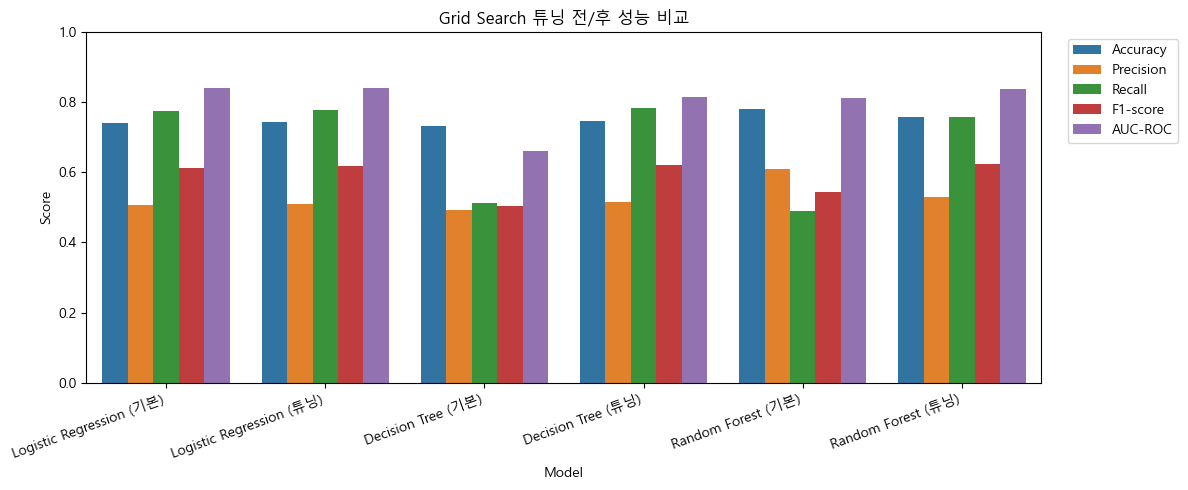

In [34]:
grid_models = {
    "Logistic Regression": (logit_base, grid_logit),
    "Decision Tree": (dt_base, grid_dt),
    "Random Forest": (rf_base, grid_rf),
}

grid_compare_list = []

for name, (base_model, grid_result) in grid_models.items():
    compare_df, base_res, tuned_res = compare_before_after(
        base_model,
        grid_result.best_estimator_,
        name,
        X_train_use, y_train_use,
        X_test_use, y_test_use
    )
    grid_compare_list.append(compare_df)

grid_compare_df = pd.concat(grid_compare_list, ignore_index=True)

print("\n=== Grid Search 튜닝 전/후 비교 (Test Set) ===")
display(grid_compare_df.round(4))

# F1-score 비교 시각화
plot_df = grid_compare_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Grid Search 튜닝 전/후 성능 비교")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [35]:
print("=" * 70)
print("2) Random Search 하이퍼파라미터 튜닝")
print("=" * 70)

N_ITER = 30   # 무작위 탐색 횟수 (시간에 따라 20~50 조절)

# ----- 2-1) XGBoost -----
xgb_base = XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.19),   # 0.01 ~ 0.20
    "subsample": uniform(0.6, 0.4),         # 0.6 ~ 1.0
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_lambda": uniform(0.1, 9.9),        # 0.1 ~ 10
}

random_xgb = run_random_search(
    xgb_base, xgb_param_dist, "XGBoost",
    X_train_use, y_train_use, n_iter=N_ITER
)

# ----- 2-2) LightGBM -----
lgbm_base = LGBMClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbose=-1,
    n_jobs=-1
)

lgbm_param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 12),
    "learning_rate": uniform(0.01, 0.19),
    "num_leaves": randint(20, 150),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}

random_lgbm = run_random_search(
    lgbm_base, lgbm_param_dist, "LightGBM",
    X_train_use, y_train_use, n_iter=N_ITER
)

# ----- 2-3) CatBoost -----
cat_base = CatBoostClassifier(
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=0
)

cat_param_dist = {
    "iterations": randint(100, 500),
    "depth": randint(4, 10),
    "learning_rate": uniform(0.01, 0.29),
    "l2_leaf_reg": uniform(1, 9),
}

random_cat = run_random_search(
    cat_base, cat_param_dist, "CatBoost",
    X_train_use, y_train_use, n_iter=N_ITER
)

# ----- 2-4) GBM (선택) -----
gbm_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

gbm_param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.7, 0.3),
}

random_gbm = run_random_search(
    gbm_base, gbm_param_dist, "GBM",
    X_train_use, y_train_use, n_iter=N_ITER
)

2) Random Search 하이퍼파라미터 튜닝
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[XGBoost] Random Search 완료 (29.4s)
  탐색 조합 수 : 30
  최적 파라미터: {'colsample_bytree': np.float64(0.9633063543866615), 'learning_rate': np.float64(0.05551675922672476), 'max_depth': 4, 'n_estimators': 152, 'reg_lambda': np.float64(4.945582326747874), 'subsample': np.float64(0.9942601816442402)}
  최적 CV F1    : 0.6356
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[LightGBM] Random Search 완료 (123.5s)
  탐색 조합 수 : 30
  최적 파라미터: {'colsample_bytree': np.float64(0.7615344684232164), 'learning_rate': np.float64(0.022329526950706495), 'max_depth': 6, 'n_estimators': 367, 'num_leaves': 58, 'subsample': np.float64(0.7988994023569542)}
  최적 CV F1    : 0.6312
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[CatBoost] Random Search 완료 (171.5s)
  탐색 조합 수 : 30
  최적 파라미터: {'depth': 6, 'iterations': 187, 'l2_leaf_reg': np.float64(4.003377500251196), 'learning_rate': np.float64(0.05143137

In [36]:
random_models = {
    "XGBoost": (xgb_base, random_xgb),
    "LightGBM": (lgbm_base, random_lgbm),
    "CatBoost": (cat_base, random_cat),
    "GBM": (gbm_base, random_gbm),
}

random_compare_list = []

for name, (base_model, random_result) in random_models.items():
    compare_df, base_res, tuned_res = compare_before_after(
        base_model,
        random_result.best_estimator_,
        name,
        X_train_use, y_train_use,
        X_test_use, y_test_use
    )
    random_compare_list.append(compare_df)

random_compare_df = pd.concat(random_compare_list, ignore_index=True)

print("\n=== Random Search 튜닝 전/후 비교 (Test Set) ===")
display(random_compare_df.round(4))


=== Random Search 튜닝 전/후 비교 (Test Set) ===


,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC,Train_Time(sec)
0,XGBoost (기본),0.7559,0.5316,0.6738,0.5943,0.8173,0.164
1,XGBoost (튜닝),0.7537,0.5238,0.7941,0.6312,0.8446,0.177
2,LightGBM (기본),0.7615,0.5361,0.7540,0.6267,0.8359,0.103
3,LightGBM (튜닝),0.7551,0.5274,0.7460,0.6179,0.8366,0.655
4,CatBoost (기본),0.7559,0.5282,0.7513,0.6203,0.8355,3.745
5,CatBoost (튜닝),0.7537,0.5239,0.7914,0.6305,0.8422,0.713
6,GBM (기본),0.8027,0.6678,0.5107,0.5788,0.8435,1.004
7,GBM (튜닝),0.8048,0.6713,0.5187,0.5852,0.8422,1.362


In [48]:
tuned_summary = []

for name, search_obj in [
    ("Logistic Regression", grid_logit),
    ("Decision Tree", grid_dt),
    ("Random Forest", grid_rf),
    ("XGBoost", random_xgb),
    ("LightGBM", random_lgbm),
    ("CatBoost", random_cat),
    ("GBM", random_gbm),
]:
    best_model = search_obj.best_estimator_
    test_res = evaluate_classifier(
        best_model, X_train_use, y_train_use,
        X_test_use, y_test_use,
        model_name=name, verbose=False
    )

    tuned_summary.append({
        "Model": name,
        "CV F1": round(search_obj.best_score_, 4),
        "Test F1": round(test_res["metrics"]["F1-score"], 4),
        "Test Recall": round(test_res["metrics"]["Recall"], 4),
        "Test AUC-ROC": round(test_res["metrics"]["AUC-ROC"], 4),
        "Best Params": search_obj.best_params_,
    })

tuned_summary_df = pd.DataFrame(tuned_summary).sort_values("Test F1", ascending=False)
print("\n=== 전체 튜닝 모델 요약 ===")
display(tuned_summary_df)

# 최종 best 모델 저장
best_row = tuned_summary_df.iloc[0]
print(f"\n최종 Best 모델: {best_row['Model']}")
print(f"Test F1: {best_row['Test F1']}")

# tuned_summary 루프 이후에 반드시 추가
search_map = {
    "Logistic Regression": grid_logit,
    "Decision Tree": grid_dt,
    "Random Forest": grid_rf,
    "XGBoost": random_xgb,
    "LightGBM": random_lgbm,
    "CatBoost": random_cat,
    "GBM": random_gbm,
}

best_model_name = tuned_summary_df.iloc[0]["Model"]
best_model = search_map[best_model_name].best_estimator_

print(f"변수 선택에 사용할 best_model: {best_model_name}")
print(type(best_model))


=== 전체 튜닝 모델 요약 ===


,Model,CV F1,Test F1,Test Recall,Test AUC-ROC,Best Params
3,XGBoost,0.6356,0.6312,0.7941,0.8446,"{'colsample_bytree': 0.9633063543866615, 'lear..."
5,CatBoost,0.6353,0.6305,0.7914,0.8422,"{'depth': 6, 'iterations': 187, 'l2_leaf_reg':..."
2,Random Forest,0.6382,0.6220,0.7567,0.8374,"{'max_depth': 8, 'max_features': 'sqrt', 'min_..."
1,Decision Tree,0.6194,0.6208,0.7834,0.8144,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s..."
4,LightGBM,0.6312,0.6179,0.7460,0.8366,"{'colsample_bytree': 0.7615344684232164, 'lear..."
0,Logistic Regression,0.6290,0.6165,0.7781,0.8391,"{'C': 0.1, 'solver': 'lbfgs'}"
6,GBM,0.5842,0.5852,0.5187,0.8422,"{'learning_rate': 0.09539562808625864, 'max_de..."



최종 Best 모델: XGBoost
Test F1: 0.6312
변수 선택에 사용할 best_model: XGBoost
<class 'xgboost.sklearn.XGBClassifier'>


In [49]:
# 1) 현재 best_model이 XGBoost인지
print("best_model:", type(best_model))

# 2) 동일 데이터로 F1 재확인
check = evaluate_classifier(
    best_model, X_train_use, y_train_use,
    X_test_use, y_test_use,
    model_name="check", verbose=False
)
print("튜닝 당시와 동일해야 함:", check["metrics"]["F1-score"])  # 0.6312 근처

best_model: <class 'xgboost.sklearn.XGBClassifier'>
튜닝 당시와 동일해야 함: 0.6312433581296493


**[과제]** 써니는 변수 선택이 모델 성능 향상에 도움이 되는지 궁금해졌습니다.

AI와 상의하여 본 데이터에 적합한 변수 선택법 (Feature Importance, mRMR, Boruta 등)을 결정하고 관련 코드를 작성해 보세요.

이후 전체 변수를 사용한 경우와 변수 선택법을 적용한 경우의 모델 성능을 비교해 보세요.

In [38]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from mrmr import mrmr_classif
from boruta import BorutaPy

# ----- 전처리 데이터 -----
X_train_use, X_test_use, y_train_use, y_test_use = preprocessed["base"]

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----- best_model (이전 튜닝 셀에서 생성된 최적 모델) -----
# 예시: tuned_summary_df에서 F1 최고 모델 사용
# best_model = random_xgb.best_estimator_
# 또는 직접 지정:
# best_model = grid_rf.best_estimator_

# feature name 확보
if hasattr(X_train_use, "columns"):
    feature_names = X_train_use.columns.tolist()
    X_train_df = X_train_use.copy()
    X_test_df = X_test_use.copy()
else:
    # 전처리 파이프라인에서 feature_names를 저장했다면 사용
    # feature_names = list(preprocessor.get_feature_names_out())
    feature_names = [f"feat_{i}" for i in range(X_train_use.shape[1])]
    X_train_df = pd.DataFrame(X_train_use, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_use, columns=feature_names)

y_train = pd.Series(y_train_use).reset_index(drop=True)
y_test = pd.Series(y_test_use).reset_index(drop=True)

print(f"Train shape: {X_train_df.shape}, Test shape: {X_test_df.shape}")

Train shape: (5634, 39), Test shape: (1409, 39)


In [46]:
def evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """테스트셋 성능 평가"""
    model = clone(model)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "Model": model_name,
        "변수 수": X_train.shape[1],
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1-score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_proba), 4) if y_proba is not None else np.nan,
    }
    return metrics, model, y_pred


def cv_f1_score(model, X, y, feature_list, cv=CV):
    """선택 변수 subset에 대해 CV F1 평균 계산"""
    if len(feature_list) == 0:
        return 0.0

    X_sub = X[feature_list].reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    fold_scores = []

    for train_idx, val_idx in cv.split(X_sub, y):
        X_tr, X_val = X_sub.iloc[train_idx], X_sub.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_val)
        fold_scores.append(f1_score(y_val, pred, zero_division=0))

    return np.mean(fold_scores)

1) Feature Importance 변수 선택


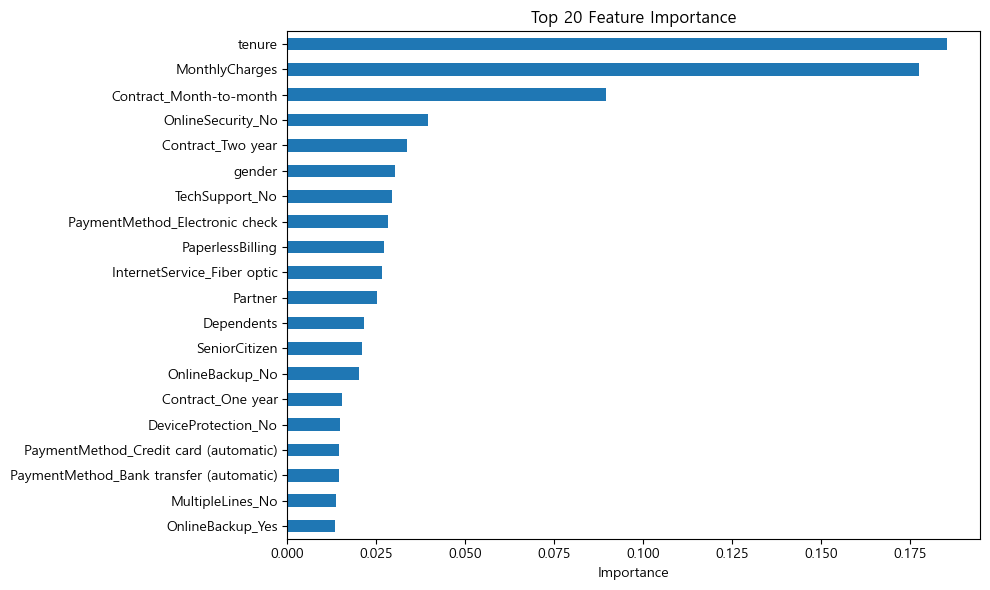

k 후보: [5, 7, 10, 12, 15, 20, 25, 30]
k= 5 | 변수 수=5 | CV F1=0.6244
k= 7 | 변수 수=7 | CV F1=0.6289
k=10 | 변수 수=10 | CV F1=0.6315
k=12 | 변수 수=12 | CV F1=0.6286
k=15 | 변수 수=15 | CV F1=0.6335
k=20 | 변수 수=20 | CV F1=0.6322
k=25 | 변수 수=25 | CV F1=0.6362
k=30 | 변수 수=30 | CV F1=0.6342

[Feature Importance] 최적 k: 25 (CV F1=0.6362)
선택 변수 (25개):
['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'OnlineSecurity_No', 'Contract_Two year', 'gender', 'TechSupport_No', 'PaymentMethod_Electronic check', 'PaperlessBilling', 'InternetService_Fiber optic', 'Partner', 'Dependents', 'SeniorCitizen', 'OnlineBackup_No', 'Contract_One year', 'DeviceProtection_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Bank transfer (automatic)', 'MultipleLines_No', 'OnlineBackup_Yes', 'TechSupport_Yes', 'MultipleLines_Yes', 'DeviceProtection_Yes', 'PaymentMethod_Mailed check', 'StreamingMovies_Yes']


In [50]:
print("=" * 70)
print("1) Feature Importance 변수 선택")
print("=" * 70)

# 중요도 계산용 RF (train만 사용)
rf_importance = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_importance.fit(X_train_df, y_train)

importance_series = (
    pd.Series(rf_importance.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
)

# 시각화
plt.figure(figsize=(10, 6))
importance_series.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ----- top_k 하이퍼파라미터 탐색 -----
k_candidates = [k for k in [5, 7, 10, 12, 15, 20, 25, 30] if k <= X_train_df.shape[1]]
print("k 후보:", k_candidates)

k_scores = {}
selected_by_k = {}

for k in k_candidates:
    selected = importance_series.head(k).index.tolist()
    selected_by_k[k] = selected

    # CV 평가: best_model 기준으로 k 탐색
    score = cv_f1_score(best_model, X_train_df, y_train, selected)
    k_scores[k] = score
    print(f"k={k:2d} | 변수 수={len(selected)} | CV F1={score:.4f}")

best_k_importance = max(k_scores, key=k_scores.get)
selected_importance = selected_by_k[best_k_importance]

print(f"\n[Feature Importance] 최적 k: {best_k_importance} (CV F1={k_scores[best_k_importance]:.4f})")
print(f"선택 변수 ({len(selected_importance)}개):")
print(selected_importance)

In [51]:
print("X index:", X_train_df.index[:5].tolist())
print("y index:", y_train.index[:5].tolist())
print("인덱스 일치:", np.all(X_train_df.index == y_train.index))

X index: [0, 1, 2, 3, 4]
y index: [0, 1, 2, 3, 4]
인덱스 일치: True


In [52]:
# X, y 인덱스를 0부터 연속으로 맞춤
X_train_df = pd.DataFrame(X_train_use, columns=feature_names).reset_index(drop=True)
X_test_df  = pd.DataFrame(X_test_use,  columns=feature_names).reset_index(drop=True)

y_train = pd.Series(y_train_use, name="Churn").reset_index(drop=True)
y_test  = pd.Series(y_test_use,  name="Churn").reset_index(drop=True)

# 확인
assert np.all(X_train_df.index == y_train.index), "X와 y 인덱스가 아직 다릅니다"
print("인덱스 정렬 완료:", X_train_df.shape, y_train.shape)

인덱스 정렬 완료: (5634, 39) (5634,)


In [53]:
print("=" * 70)
print("2) mRMR 변수 선택")
print("=" * 70)

k_candidates = [k for k in [5, 7, 10, 12, 15, 20, 25, 30] if k <= X_train_df.shape[1]]
print("k 후보:", k_candidates)

k_scores_mrmr = {}
selected_mrmr_by_k = {}

for k in k_candidates:
    # train 전체 기준 mRMR 변수 선택 (Day 12 방식)
    selected = mrmr_classif(X=X_train_df, y=y_train, K=k)
    selected_mrmr_by_k[k] = selected

    score = cv_f1_score(best_model, X_train_df, y_train, selected)
    k_scores_mrmr[k] = score
    print(f"k={k:2d} | 변수 수={len(selected)} | CV F1={score:.4f}")

best_k_mrmr = max(k_scores_mrmr, key=k_scores_mrmr.get)
selected_mrmr = selected_mrmr_by_k[best_k_mrmr]
removed_mrmr = [c for c in feature_names if c not in selected_mrmr]

print(f"\n[mRMR] 최적 k: {best_k_mrmr} (CV F1={k_scores_mrmr[best_k_mrmr]:.4f})")
print(f"선택 변수 ({len(selected_mrmr)}개):")
print(selected_mrmr)
print(f"제거 변수: {len(removed_mrmr)}개")

2) mRMR 변수 선택
k 후보: [5, 7, 10, 12, 15, 20, 25, 30]


100%|██████████| 5/5 [00:00<00:00, 18.33it/s]


k= 5 | 변수 수=5 | CV F1=0.6175


100%|██████████| 7/7 [00:00<00:00, 24.85it/s]


k= 7 | 변수 수=7 | CV F1=0.6276


...

k=20 | 변수 수=20 | CV F1=0.6340


100%|██████████| 25/25 [00:01<00:00, 19.05it/s]


k=25 | 변수 수=25 | CV F1=0.6356


100%|██████████| 30/30 [00:01<00:00, 23.40it/s]


k=30 | 변수 수=30 | CV F1=0.6330

[mRMR] 최적 k: 25 (CV F1=0.6356)
선택 변수 (25개):
['Contract_Month-to-month', 'PaymentMethod_Mailed check', 'OnlineSecurity_No', 'InternetService_DSL', 'tenure', 'TechSupport_No', 'PaymentMethod_Electronic check', 'InternetService_Fiber optic', 'Contract_Two year', 'OnlineBackup_No', 'PaperlessBilling', 'DeviceProtection_No', 'Contract_One year', 'Dependents', 'OnlineSecurity_Yes', 'InternetService_No', 'SeniorCitizen', 'OnlineSecurity_No internet service', 'PaymentMethod_Credit card (automatic)', 'Partner', 'OnlineBackup_No internet service', 'TechSupport_Yes', 'DeviceProtection_No internet service', 'PaymentMethod_Bank transfer (automatic)', 'TechSupport_No internet service']
제거 변수: 14개


In [54]:
print("=" * 70)
print("3) Boruta 변수 선택")
print("=" * 70)

rf_boruta = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

max_iter_candidates = [20, 30, 50, 70]
perc_candidates = [90, 100]

boruta_scores = {}
boruta_selected = {}

for max_iter in max_iter_candidates:
    for perc in perc_candidates:
        selector = BorutaPy(
            estimator=rf_boruta,
            n_estimators="auto",
            max_iter=max_iter,
            perc=perc,
            random_state=RANDOM_STATE,
            verbose=0
        )

        selector.fit(X_train_df.values, y_train.values.ravel())

        # 확정 + 미정(tentative) 변수 모두 사용 (Day 12 방식)
        selected_mask = selector.support_ | selector.support_weak_
        selected = X_train_df.columns[selected_mask].tolist()

        # 변수가 0개면 스킵
        if len(selected) == 0:
            score = 0.0
        else:
            score = cv_f1_score(best_model, X_train_df, y_train, selected)

        key = (max_iter, perc)
        boruta_scores[key] = score
        boruta_selected[key] = selected

        print(f"max_iter={max_iter:2d}, perc={perc:3d} | 선택={len(selected):2d}개 | CV F1={score:.4f}")

best_boruta_params = max(boruta_scores, key=boruta_scores.get)
best_max_iter, best_perc = best_boruta_params
selected_boruta = boruta_selected[best_boruta_params]

boruta_confirmed = X_train_df.columns[
    BorutaPy(
        rf_boruta, n_estimators="auto",
        max_iter=best_max_iter, perc=best_perc,
        random_state=RANDOM_STATE, verbose=0
    ).fit(X_train_df.values, y_train.values.ravel()).support_
].tolist()

print(f"\n[Boruta] 최적 파라미터: max_iter={best_max_iter}, perc={best_perc}")
print(f"CV F1={boruta_scores[best_boruta_params]:.4f}")
print(f"선택 변수 ({len(selected_boruta)}개):")
print(selected_boruta)

3) Boruta 변수 선택
max_iter=20, perc= 90 | 선택=12개 | CV F1=0.6291
max_iter=20, perc=100 | 선택= 3개 | CV F1=0.6193
max_iter=30, perc= 90 | 선택=12개 | CV F1=0.6291
max_iter=30, perc=100 | 선택= 3개 | CV F1=0.6193
max_iter=50, perc= 90 | 선택=12개 | CV F1=0.6291
max_iter=50, perc=100 | 선택= 3개 | CV F1=0.6193
max_iter=70, perc= 90 | 선택=12개 | CV F1=0.6291
max_iter=70, perc=100 | 선택= 3개 | CV F1=0.6193

[Boruta] 최적 파라미터: max_iter=20, perc=90
CV F1=0.6291
선택 변수 (12개):
['tenure', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_Fiber optic', 'OnlineSecurity_No', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'TechSupport_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Electronic check']


4) 전체 변수 vs 변수 선택 성능 비교 (Test Set)

=== 전체 변수 (39개) ===
  Accuracy: 0.7537
  Precision: 0.5238
  Recall: 0.7941
  F1-score: 0.6312
  AUC-ROC: 0.8446

=== Feature Importance (25개) ===
  선택 변수: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'OnlineSecurity_No', 'Contract_Two year', 'gender', 'TechSupport_No', 'PaymentMethod_Electronic check', 'PaperlessBilling', 'InternetService_Fiber optic', 'Partner', 'Dependents', 'SeniorCitizen', 'OnlineBackup_No', 'Contract_One year', 'DeviceProtection_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Bank transfer (automatic)', 'MultipleLines_No', 'OnlineBackup_Yes', 'TechSupport_Yes', 'MultipleLines_Yes', 'DeviceProtection_Yes', 'PaymentMethod_Mailed check', 'StreamingMovies_Yes']
  Accuracy: 0.7502
  Precision: 0.5192
  Recall: 0.7968
  F1-score: 0.6287
  AUC-ROC: 0.8429
  혼동행렬:
[[759 276]
 [ 76 298]]

=== mRMR (25개) ===
  선택 변수: ['Contract_Month-to-month', 'PaymentMethod_Mailed check', 'OnlineSecurity_No', 'InternetService_DS

,Model,변수 수,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,전체 변수,39,0.7537,0.5238,0.7941,0.6312,0.8446
1,Feature Importance (선택),25,0.7502,0.5192,0.7968,0.6287,0.8429
2,mRMR (선택),25,0.7495,0.5183,0.7941,0.6272,0.8412
3,Boruta (선택),12,0.7488,0.5177,0.7834,0.6234,0.8421


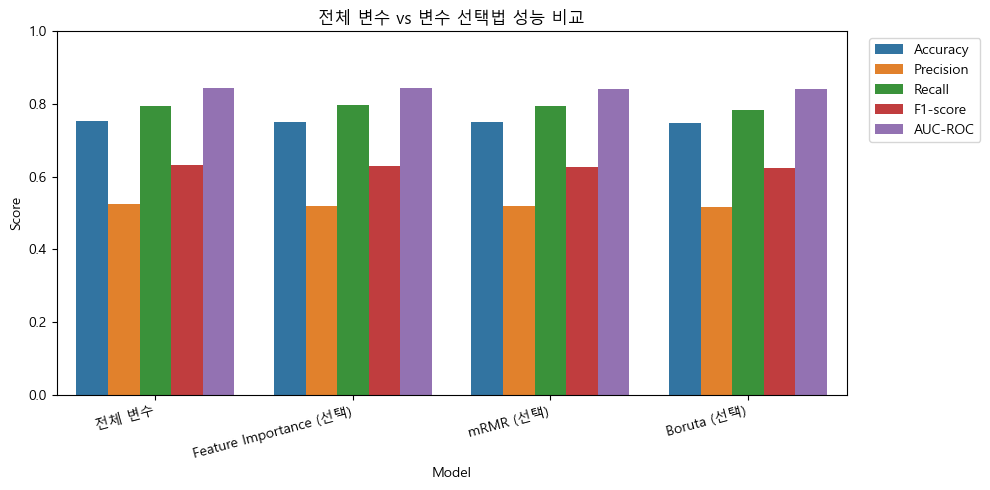

In [55]:
print("=" * 70)
print("4) 전체 변수 vs 변수 선택 성능 비교 (Test Set)")
print("=" * 70)

feature_selection_results = {
    "Feature Importance": selected_importance,
    "mRMR": selected_mrmr,
    "Boruta": selected_boruta,
}

comparison_rows = []

# (1) 전체 변수 baseline
metrics_all, model_all, _ = evaluate_on_test(
    best_model,
    X_train_df, y_train,
    X_test_df, y_test,
    model_name="전체 변수"
)
comparison_rows.append(metrics_all)

print(f"\n=== 전체 변수 ({metrics_all['변수 수']}개) ===")
for k, v in metrics_all.items():
    if k not in ["Model", "변수 수"]:
        print(f"  {k}: {v}")

# (2) 각 변수 선택법 적용
for method_name, selected_cols in feature_selection_results.items():
    metrics_sel, model_sel, y_pred_sel = evaluate_on_test(
        best_model,
        X_train_df[selected_cols], y_train,
        X_test_df[selected_cols], y_test,
        model_name=f"{method_name} (선택)"
    )
    comparison_rows.append(metrics_sel)

    print(f"\n=== {method_name} ({len(selected_cols)}개) ===")
    print(f"  선택 변수: {selected_cols}")
    for k, v in metrics_sel.items():
        if k not in ["Model", "변수 수"]:
            print(f"  {k}: {v}")
    print(f"  혼동행렬:\n{confusion_matrix(y_test, y_pred_sel)}")

# ----- 비교표 -----
comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[
    ["Model", "변수 수", "Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]
]

print("\n=== 성능 비교 요약 ===")
display(comparison_df)

# F1-score 막대그래프
plt.figure(figsize=(10, 5))
plot_df = comparison_df.melt(
    id_vars=["Model", "변수 수"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    var_name="Metric",
    value_name="Score"
)
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("전체 변수 vs 변수 선택법 성능 비교")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**[과제]** 써니는 클래스 불균형을 완화하면 모델 성능이 향상될 것이라고 생각했습니다.

AI와 상의하여 Resampling (TomekLinks, SMOTE, TomekLinks+SMOTE, ADASYN 등) 또는 One-Class Learning (SVDD 등) 중 본 데이터에 적합한 방법을 선택하고 적용해 보세요.

이후 적용 전후의 모델 성능을 비교해 보세요.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

RANDOM_STATE = 42

# ----- 전체 변수 (base) -----
X_train_base, X_test_use, y_train_base, y_test_use = preprocessed["base"]

# ADASYN은 preprocessed에 없으므로 train에서 새로 생성
X_train_adasyn, y_train_adasyn = ADASYN(random_state=RANDOM_STATE).fit_resample(
    X_train_base, y_train_base
)

# 방법 2: 언패킹 (더 읽기 쉬움)
X_tr_tl, _, y_tr_tl, _ = preprocessed["tomek"]
X_tr_sm, _, y_tr_sm, _ = preprocessed["smote"]
X_tr_st, _, y_tr_st, _ = preprocessed["smote_tomek"]

sampling_datasets = {
    "Before (원본)": (X_train_base, y_train_base),
    "TomekLinks":    (X_tr_tl, y_tr_tl),
    "SMOTE":         (X_tr_sm, y_tr_sm),
    "SMOTE+Tomek":   (X_tr_st, y_tr_st),
    "ADASYN":        (X_train_adasyn, y_train_adasyn),
}

# 튜닝된 XGBoost 하이퍼파라미터 (이전 Random Search 결과)
tuned_xgb_params = random_xgb.best_params_.copy()

def build_tuned_xgb(y_train):
    """Resampling 후 클래스 비율에 맞게 scale_pos_weight 자동 설정"""
    y_train = pd.Series(y_train)
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / max(pos, 1)

    return XGBClassifier(
        **tuned_xgb_params,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

def evaluate_resampling(name, X_tr, y_tr):
    model = build_tuned_xgb(y_tr)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_test_use)
    y_proba = model.predict_proba(X_test_use)[:, 1]

    y_te = pd.Series(y_test_use)
    neg_tr, pos_tr = (pd.Series(y_tr) == 0).sum(), (pd.Series(y_tr) == 1).sum()

    return {
        "Method": name,
        "Train No": neg_tr,
        "Train Yes": pos_tr,
        "Yes 비율(%)": round(pos_tr / (neg_tr + pos_tr) * 100, 1),
        "scale_pos_weight": round(neg_tr / max(pos_tr, 1), 2),
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_te, y_pred, zero_division=0), 4),
        "F1-score": round(f1_score(y_te, y_pred, zero_division=0), 4),
        "AUC-ROC": round(roc_auc_score(y_te, y_proba), 4),
    }, model, y_pred

# ----- 성능 비교 실행 -----
resampling_results = []
trained_models = {}

print("=" * 70)
print("Resampling 기법별 XGBoost (튜닝 파라미터) 성능 비교")
print("=" * 70)

for name, (X_tr, y_tr) in sampling_datasets.items():
    metrics, model, y_pred = evaluate_resampling(name, X_tr, y_tr)
    resampling_results.append(metrics)
    trained_models[name] = model

    print(f"\n[{name}]")
    print(f"  Train: No={metrics['Train No']}, Yes={metrics['Train Yes']} "
          f"(Yes {metrics['Yes 비율(%)']}%)")
    print(f"  scale_pos_weight={metrics['scale_pos_weight']}")
    print(f"  F1={metrics['F1-score']}, Recall={metrics['Recall']}, "
          f"AUC={metrics['AUC-ROC']}")
    print(f"  혼동행렬:\n{confusion_matrix(y_test_use, y_pred)}")

resampling_df = pd.DataFrame(resampling_results)
display(resampling_df)

Resampling 기법별 XGBoost (튜닝 파라미터) 성능 비교

[Before (원본)]
  Train: No=4139, Yes=1495 (Yes 26.5%)
  scale_pos_weight=2.77
  F1=0.6312, Recall=0.7941, AUC=0.8446
  혼동행렬:
[[765 270]
 [ 77 297]]

[TomekLinks]
  Train: No=3756, Yes=1495 (Yes 28.5%)
  scale_pos_weight=2.51
  F1=0.6325, Recall=0.8075, AUC=0.8443
  혼동행렬:
[[756 279]
 [ 72 302]]

[SMOTE]
  Train: No=4139, Yes=4139 (Yes 50.0%)
  scale_pos_weight=1.0
  F1=0.6054, Recall=0.6952, AUC=0.8408
  혼동행렬:
[[810 225]
 [114 260]]

[SMOTE+Tomek]
  Train: No=3958, Yes=3958 (Yes 50.0%)
  scale_pos_weight=1.0
  F1=0.6138, Recall=0.7032, AUC=0.8406
  혼동행렬:
[[815 220]
 [111 263]]

[ADASYN]
  Train: No=4139, Yes=4122 (Yes 49.9%)
  scale_pos_weight=1.0
  F1=0.6147, Recall=0.7273, AUC=0.8383
  혼동행렬:
[[796 239]
 [102 272]]


,Method,Train No,Train Yes,Yes 비율(%),scale_pos_weight,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Before (원본),4139,1495,26.5,2.77,0.7537,0.5238,0.7941,0.6312,0.8446
1,TomekLinks,3756,1495,28.5,2.51,0.7509,0.5198,0.8075,0.6325,0.8443
2,SMOTE,4139,4139,50.0,1.00,0.7594,0.5361,0.6952,0.6054,0.8408
3,SMOTE+Tomek,3958,3958,50.0,1.00,0.7651,0.5445,0.7032,0.6138,0.8406
4,ADASYN,4139,4122,49.9,1.00,0.7580,0.5323,0.7273,0.6147,0.8383


## 6) 모델 해석

1. SHAP Value
2. Clustering 기반 RCA
3. STUCCO 기반 RCA

**[과제]** 써니는 최종 모델의 예측 결과를 해석하고자 합니다.

가장 예측력이 좋았던 전처리 방법, 모델, 모델 고도화 방법의 조합을 선택한 뒤, AI와 상의하여 적절한 모델 해석 기법을 적용해 보세요.

이를 바탕으로 "어떤 고객이 채무불이행 위험이 높은지"를 한 문단으로 정리해 보세요.

In [58]:
# !pip install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Jupyter에서 인터랙티브 Force Plot을 쓰려면 (선택)
# shap.initjs()

In [60]:
# TomekLinks + 전체 변수 (Resampling 셀에서 생성된 모델 사용)
best_xgb = trained_models["TomekLinks"]   # 없으면 아래 주석 참고

# TomekLinks train / test
X_train_tl, X_test_tl, y_train_tl, y_test_tl = preprocessed["tomek"]

# 평가용 test는 base와 동일한 test set 사용
X_test_use, y_test_use = preprocessed["base"][1], preprocessed["base"][3]

# DataFrame 변환
if hasattr(X_train_tl, "columns"):
    X_train_df = X_train_tl.copy()
    X_test_df = X_test_use.copy()
else:
    feature_names = [f"feat_{i}" for i in range(X_train_tl.shape[1])]
    X_train_df = pd.DataFrame(X_train_tl, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_use, columns=feature_names)

y_train = pd.Series(y_train_tl).reset_index(drop=True)
y_test = pd.Series(y_test_use).reset_index(drop=True)

X_shap = X_train_df.sample(min(2000, len(X_train_df)), random_state=42)
print(f"Best model: XGBoost (TomekLinks)")
print(f"SHAP 계산 데이터: {X_shap.shape}")

Best model: XGBoost (TomekLinks)
SHAP 계산 데이터: (2000, 39)


In [61]:
# TreeExplainer (XGBoost는 Tree 기반)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)

# 이탈(Churn=1) 클래스 SHAP 추출
if isinstance(shap_values, list):
    shap_churn = shap_values[1]          # [0]=유지, [1]=이탈
    expected_value = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    shap_churn = shap_values[:, :, 1]     # (샘플, 변수, 클래스)
    expected_value = explainer.expected_value[1]
else:
    shap_churn = shap_values             # XGBoost 단일 출력인 경우
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1]

print(f"SHAP shape: {shap_churn.shape}")

SHAP shape: (2000, 39)


In [62]:
# 평균 |SHAP| 기준 상위 10개
mean_abs_shap = pd.Series(
    np.abs(shap_churn).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

top10_features = mean_abs_shap.head(10).index.tolist()

print("=== 이탈(Churn=1) 예측에 영향 큰 상위 10개 변수 ===")
display(mean_abs_shap.head(10).round(4))

print("\n상위 10개 변수 목록:")
print(top10_features)

=== 이탈(Churn=1) 예측에 영향 큰 상위 10개 변수 ===


Contract_Month-to-month           0.8027
tenure                            0.5476
MonthlyCharges                    0.2960
OnlineSecurity_No                 0.2652
TechSupport_No                    0.2323
InternetService_Fiber optic       0.2045
PaymentMethod_Electronic check    0.1920
PaperlessBilling                  0.1334
Contract_Two year                 0.1209
MultipleLines_No                  0.1012
dtype: float32


상위 10개 변수 목록:
['Contract_Month-to-month', 'tenure', 'MonthlyCharges', 'OnlineSecurity_No', 'TechSupport_No', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'PaperlessBilling', 'Contract_Two year', 'MultipleLines_No']


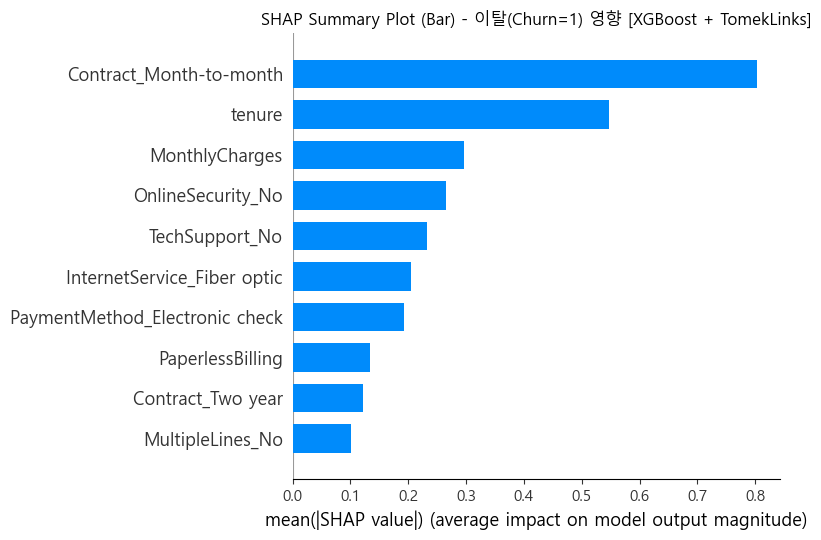

In [63]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_churn,
    X_shap,
    plot_type="bar",
    max_display=10,
    show=False,
)
plt.title("SHAP Summary Plot (Bar) - 이탈(Churn=1) 영향 [XGBoost + TomekLinks]")
plt.tight_layout()
plt.show()

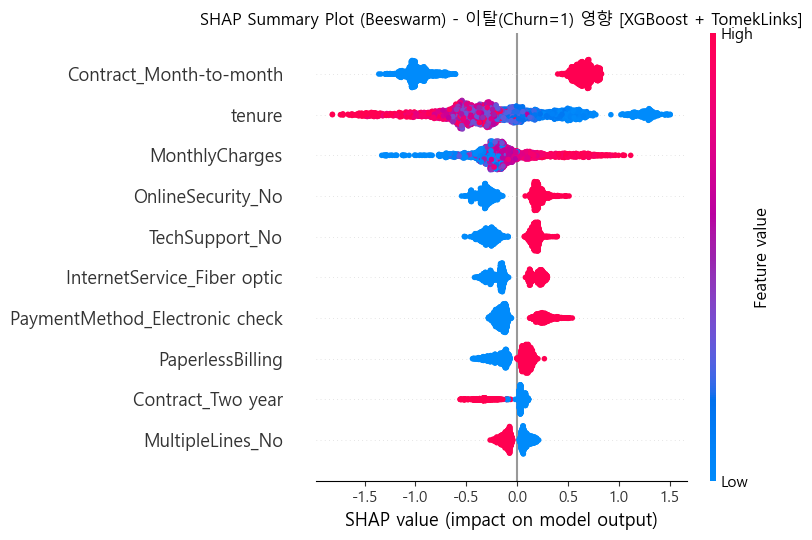

In [64]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_churn,
    X_shap,
    max_display=10,
    show=False,
)
plt.title("SHAP Summary Plot (Beeswarm) - 이탈(Churn=1) 영향 [XGBoost + TomekLinks]")
plt.tight_layout()
plt.show()

테스트셋에서 이탈로 예측된 고객 수: 581명

선택 고객 (테스트 index): 6866
실제 Churn: 1 | 예측 Churn: 1
이탈 확률: 0.9755


<Figure size 1400x300 with 0 Axes>

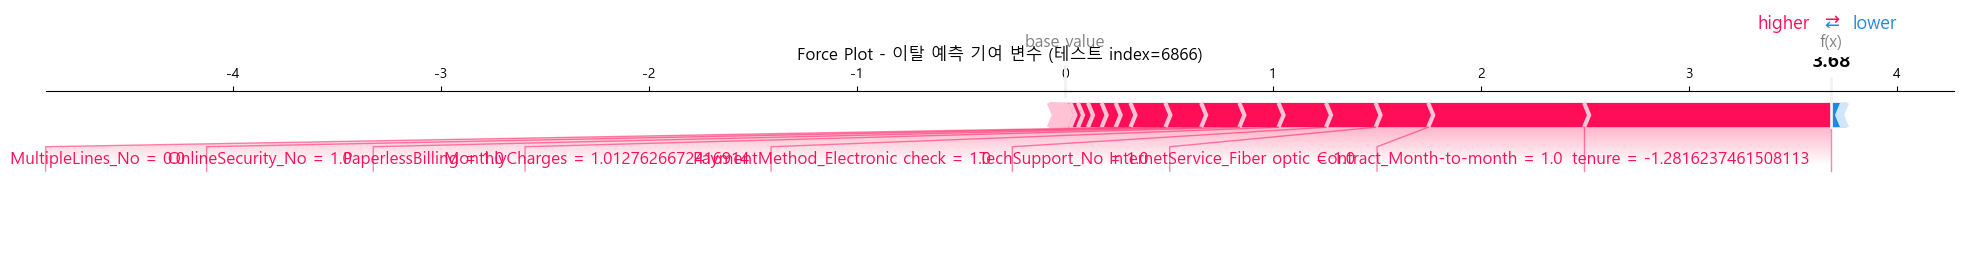

In [65]:
# 테스트셋에서 이탈(1)로 예측된 고객 찾기
y_pred_test = best_xgb.predict(X_test_df)
y_proba_test = best_xgb.predict_proba(X_test_df)[:, 1]

churn_pred_idx = np.where(y_pred_test == 1)[0]
print(f"테스트셋에서 이탈로 예측된 고객 수: {len(churn_pred_idx)}명")

# 이탈 확률이 가장 높은 고객 1명 선택 (또는 churn_pred_idx[0])
sample_pos = churn_pred_idx[np.argmax(y_proba_test[churn_pred_idx])]
sample_idx = X_test_df.index[sample_pos]

sample_X = X_test_df.iloc[[sample_pos]]
print(f"\n선택 고객 (테스트 index): {sample_idx}")
print(f"실제 Churn: {y_test.iloc[sample_pos]} | 예측 Churn: {y_pred_test[sample_pos]}")
print(f"이탈 확률: {y_proba_test[sample_pos]:.4f}")

# 해당 고객 SHAP 계산
shap_values_sample = explainer.shap_values(sample_X)

if isinstance(shap_values_sample, list):
    shap_sample = shap_values_sample[1][0]
elif len(np.array(shap_values_sample).shape) == 3:
    shap_sample = shap_values_sample[0, :, 1]
else:
    shap_sample = shap_values_sample[0]

# Force Plot (정적 이미지)
plt.figure(figsize=(14, 3))
shap.force_plot(
    expected_value,
    shap_sample,
    sample_X.iloc[0],
    matplotlib=True,
    show=False,
)
plt.title(f"Force Plot - 이탈 예측 기여 변수 (테스트 index={sample_idx})")
plt.tight_layout()
plt.show()

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# base = 리샘플링 전 원본 train (4개 언패킹)
X_train_base, X_test_base, y_train_base, y_test_base = preprocessed["base"]

# RCA용: train + test 합쳐서 전체 고객 세그먼트 분석
X_all = pd.concat([X_train_base, X_test_base], axis=0).reset_index(drop=True)
y_all = pd.concat([y_train_base, y_test_base], axis=0).reset_index(drop=True)

# 분석용 DataFrame (Churn 라벨 포함)
rca_df = X_all.copy()
rca_df["Churn"] = y_all.values

X_cluster = X_all.values   # 군집화는 피처만 사용 (Churn 제외)
print(f"RCA 데이터: {X_cluster.shape}, 전체 이탈률: {y_all.mean()*100:.1f}%")

RCA 데이터: (7043, 39), 전체 이탈률: 26.5%


최적 K: 2 (Silhouette Score: 0.288)


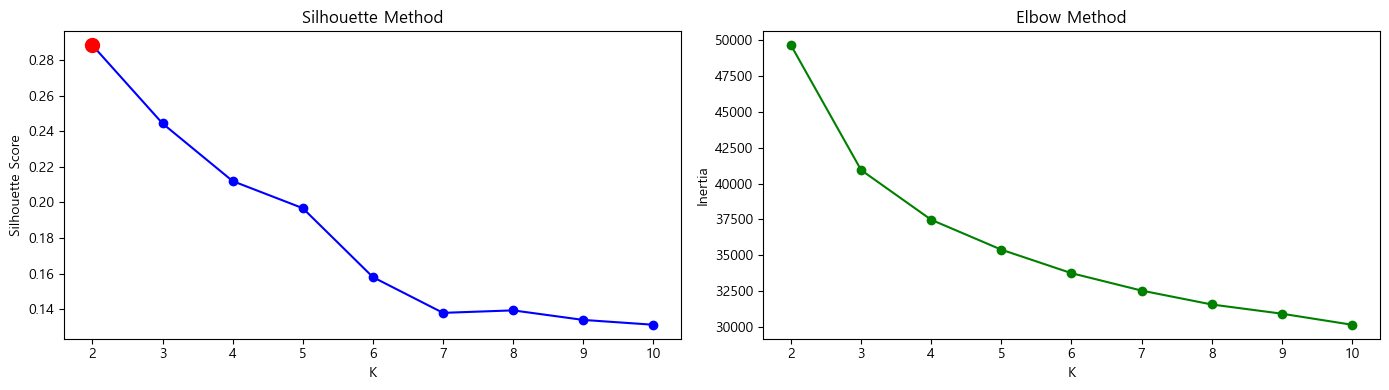

In [67]:
# ── 1-1) K 후보 탐색 (Silhouette Score) ──
K_range = range(2, 11)
sil_scores = []
inertias = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    sil_scores.append(silhouette_score(X_cluster, labels))
    inertias.append(kmeans.inertia_)

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"최적 K: {best_k} (Silhouette Score: {max(sil_scores):.3f})")

# Silhouette Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, sil_scores, "bo-")
axes[0].scatter(best_k, max(sil_scores), c="red", s=100, zorder=5)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Method")
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, inertias, "go-")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Inertia")
axes[1].set_title("Elbow Method")
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

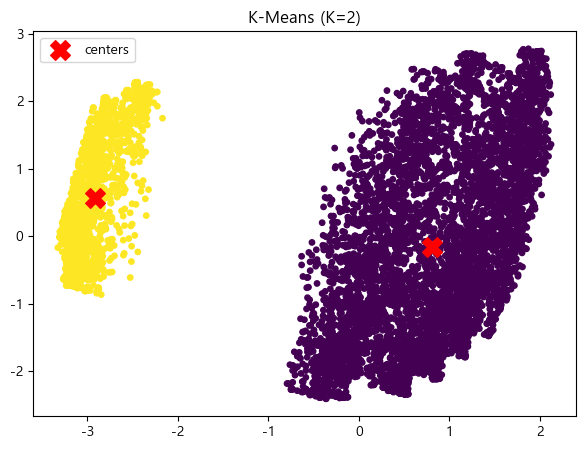

In [68]:
# ── 1-2) 최적 K로 최종 K-Means 학습 ──
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rca_df["cluster_kmeans"] = kmeans_best.fit_predict(X_cluster)

# 시각화 (PCA 2차원 축소)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rca_df["cluster_kmeans"], s=15, cmap="viridis")
centers_pca = pca.transform(kmeans_best.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c="red", marker="X", s=200, label="centers")
plt.title(f"K-Means (K={best_k})")
plt.legend()
plt.show()

=== K-Means 군집별 Churn 분석 ===


,고객수,이탈수,이탈률,이탈률(%)
cluster_kmeans,,,,
0,5517,1756,0.318289,31.8
1,1526,113,0.074050,7.4



이탈률 최고 군집: Cluster 0 (31.8%)


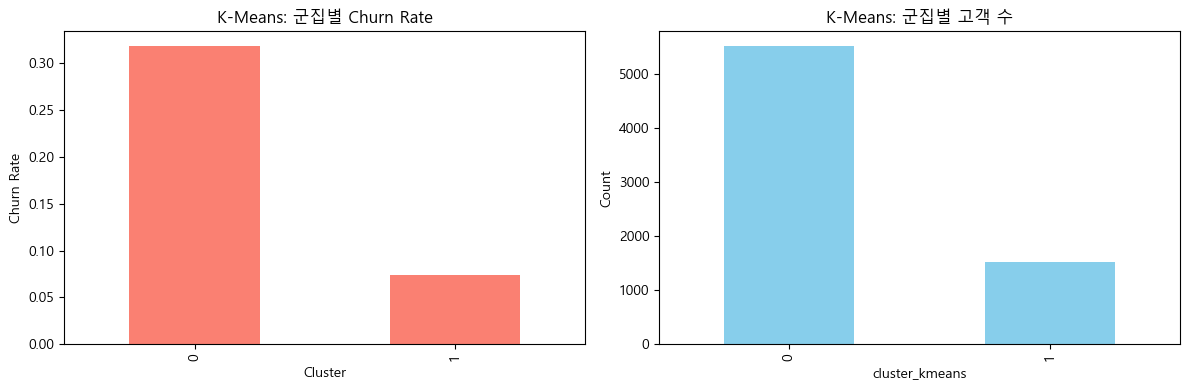

In [69]:
# ── 1-3) K-Means RCA: 군집별 이탈률 ──
kmeans_churn = (
    rca_df.groupby("cluster_kmeans")["Churn"]
    .agg(고객수="count", 이탈수="sum", 이탈률=lambda x: x.mean())
    .sort_values("이탈률", ascending=False)
)
kmeans_churn["이탈률(%)"] = (kmeans_churn["이탈률"] * 100).round(1)

print("=== K-Means 군집별 Churn 분석 ===")
display(kmeans_churn)

# 이탈률 가장 높은 군집
high_churn_cluster_km = kmeans_churn.index[0]
print(f"\n이탈률 최고 군집: Cluster {high_churn_cluster_km} "
      f"({kmeans_churn.loc[high_churn_cluster_km, '이탈률(%)']}%)")

# 막대그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kmeans_churn["이탈률"].plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("K-Means: 군집별 Churn Rate")
axes[0].set_ylabel("Churn Rate")
axes[0].set_xlabel("Cluster")

rca_df.groupby("cluster_kmeans")["Churn"].count().plot(kind="bar", ax=axes[1], color="skyblue")
axes[1].set_title("K-Means: 군집별 고객 수")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [70]:
# ── 1-4) 고이탈 군집 프로파일 (주요 변수 비교) ──
# 수치형 + 주요 더미 변수 (컬럼명에 맞게 조정)
key_cols = [c for c in rca_df.columns if c in ["tenure", "MonthlyCharges"] 
            or c.startswith(("Contract_", "InternetService_", "PaymentMethod_"))]

high = rca_df[rca_df["cluster_kmeans"] == high_churn_cluster_km]
low  = rca_df[rca_df["cluster_kmeans"] != high_churn_cluster_km]

profile = pd.DataFrame({
    "고이탈군집_평균": high[key_cols].mean(),
    "나머지군집_평균": low[key_cols].mean(),
})
profile["차이"] = profile["고이탈군집_평균"] - profile["나머지군집_평균"]
profile = profile.reindex(profile["차이"].abs().sort_values(ascending=False).index)

print(f"\n=== Cluster {high_churn_cluster_km} (고이탈) vs 나머지 군집 특성 ===")
display(profile.head(10).round(3))


=== Cluster 0 (고이탈) vs 나머지 군집 특성 ===


,고이탈군집_평균,나머지군집_평균,차이
MonthlyCharges,0.395,-1.455,1.850
InternetService_No,0.000,1.000,-1.000
InternetService_Fiber optic,0.561,0.000,0.561
InternetService_DSL,0.439,0.000,0.439
PaymentMethod_Mailed check,0.158,0.486,-0.328
PaymentMethod_Electronic check,0.407,0.080,0.327
Contract_Month-to-month,0.607,0.343,0.264
Contract_Two year,0.192,0.418,-0.226
tenure,0.016,-0.079,0.095
Contract_One year,0.201,0.239,-0.038


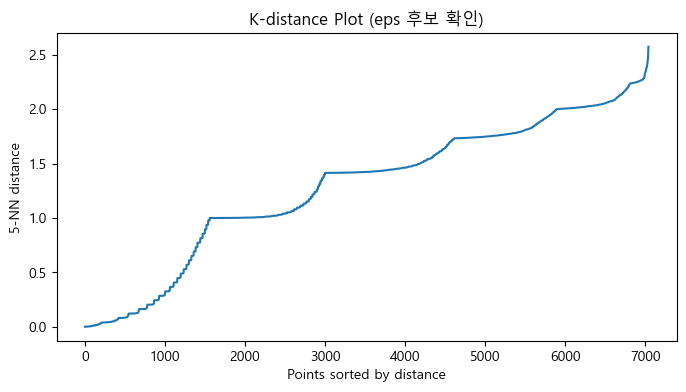

In [71]:
# ── 2-1) K-distance Plot (eps 후보 확인) ──
min_samples = 5   # 보통 feature수의 2배 근처 (39개 → 5~10)

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_cluster)
distances, _ = neighbors_fit.kneighbors(X_cluster)
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (eps 후보 확인)")
plt.show()

In [72]:
# ── 2-2) eps × min_samples for문 탐색 ──
eps_range = np.arange(1.0, 4.5, 0.3)          # K-distance elbow 근처로 조정
min_samples_range = [3, 5, 7, 10]

best_score = -1
best_params = {}
results = []

for eps in eps_range:
    for ms in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(X_cluster)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        # 유효 조건: 군집 2개 이상, 노이즈 50% 미만
        if n_clusters < 2 or n_noise / len(labels) > 0.5:
            continue

        # 노이즈 제외하고 Silhouette 계산
        mask = labels != -1
        score = silhouette_score(X_cluster[mask], labels[mask])

        results.append({
            "eps": eps, "min_samples": ms,
            "n_clusters": n_clusters, "n_noise": n_noise,
            "silhouette": score
        })

        if score > best_score:
            best_score = score
            best_params = {"eps": eps, "min_samples": ms, "n_clusters": n_clusters}

results_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
print("=== DBSCAN 파라미터 탐색 결과 (상위 5개) ===")
display(results_df.head())

print(f"\n최적 파라미터: eps={best_params['eps']}, "
      f"min_samples={best_params['min_samples']}, "
      f"군집 수={best_params['n_clusters']}, "
      f"Silhouette={best_score:.3f}")

=== DBSCAN 파라미터 탐색 결과 (상위 5개) ===


,eps,min_samples,n_clusters,n_noise,silhouette
11,2.2,7,2,52,0.289432
10,2.2,5,2,29,0.288857
9,2.2,3,2,20,0.288685
29,3.7,3,2,0,0.288228
13,2.5,3,2,0,0.288228



최적 파라미터: eps=2.2, min_samples=7, 군집 수=2, Silhouette=0.289


군집 수: 2, 노이즈: 52 (0.7%)


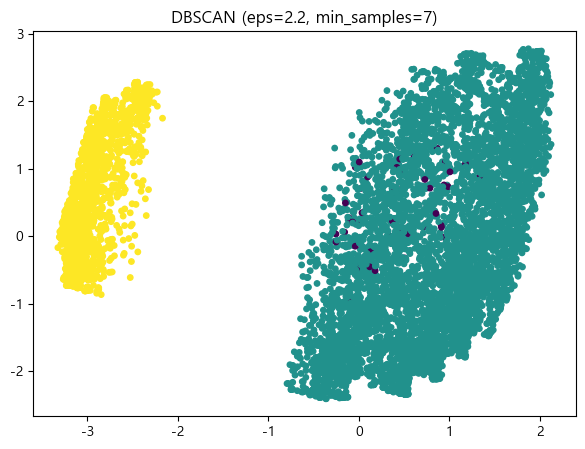

In [73]:
# ── 2-3) 최적 파라미터로 DBSCAN 학습 ──
dbscan_best = DBSCAN(eps=best_params["eps"], min_samples=best_params["min_samples"])
rca_df["cluster_dbscan"] = dbscan_best.fit_predict(X_cluster)

n_clusters = len(set(rca_df["cluster_dbscan"])) - (1 if -1 in rca_df["cluster_dbscan"].values else 0)
n_noise = (rca_df["cluster_dbscan"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise} ({n_noise/len(rca_df)*100:.1f}%)")

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rca_df["cluster_dbscan"], s=15, cmap="viridis")
plt.title(f"DBSCAN (eps={best_params['eps']}, min_samples={best_params['min_samples']})")
plt.show()

=== DBSCAN 군집별 Churn 분석 ===


,고객수,이탈수,이탈률,이탈률(%)
cluster_dbscan,,,,
0,5465,1751,0.320403,32.0
-1,52,5,0.096154,9.6
1,1526,113,0.074050,7.4



이탈률 최고 군집: Cluster 0 (32.0%)


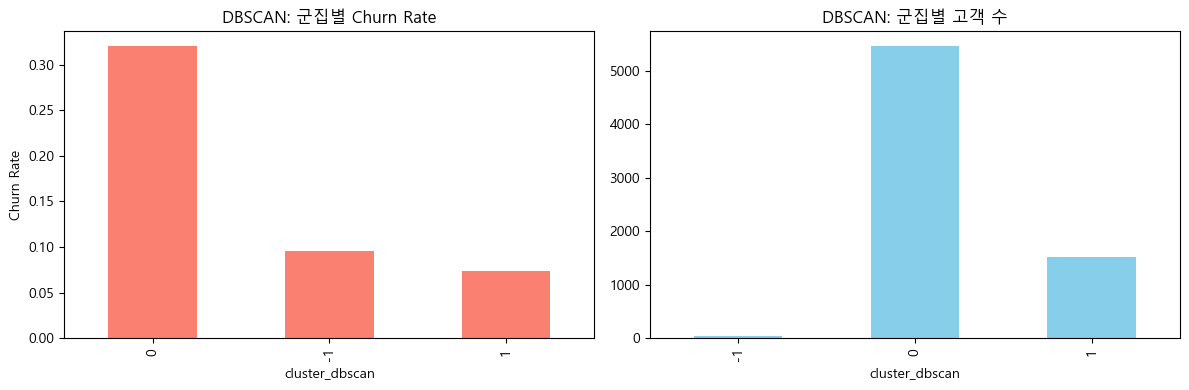

In [74]:
# ── 2-4) DBSCAN RCA: 군집별 이탈률 (노이즈 -1 별도 표시) ──
dbscan_churn = (
    rca_df.groupby("cluster_dbscan")["Churn"]
    .agg(고객수="count", 이탈수="sum", 이탈률=lambda x: x.mean())
    .sort_values("이탈률", ascending=False)
)
dbscan_churn["이탈률(%)"] = (dbscan_churn["이탈률"] * 100).round(1)

print("=== DBSCAN 군집별 Churn 분석 ===")
display(dbscan_churn)

# 노이즈(-1) 제외하고 이탈률 최고 군집
valid_clusters = dbscan_churn.index[dbscan_churn.index != -1]
high_churn_cluster_db = valid_clusters[0] if len(valid_clusters) > 0 else -1
print(f"\n이탈률 최고 군집: Cluster {high_churn_cluster_db} "
      f"({dbscan_churn.loc[high_churn_cluster_db, '이탈률(%)']}%)")

# 막대그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dbscan_churn["이탈률"].plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("DBSCAN: 군집별 Churn Rate")
axes[0].set_ylabel("Churn Rate")

rca_df.groupby("cluster_dbscan")["Churn"].count().plot(kind="bar", ax=axes[1], color="skyblue")
axes[1].set_title("DBSCAN: 군집별 고객 수")

plt.tight_layout()
plt.show()

In [75]:
# ── 2-5) DBSCAN 고이탈 군집 프로파일 ──
if high_churn_cluster_db != -1:
    high_db = rca_df[rca_df["cluster_dbscan"] == high_churn_cluster_db]
    low_db  = rca_df[rca_df["cluster_dbscan"] != high_churn_cluster_db]

    profile_db = pd.DataFrame({
        "고이탈군집_평균": high_db[key_cols].mean(),
        "나머지_평균": low_db[key_cols].mean(),
    })
    profile_db["차이"] = profile_db["고이탈군집_평균"] - profile_db["나머지_평균"]
    profile_db = profile_db.reindex(profile_db["차이"].abs().sort_values(ascending=False).index)

    print(f"=== DBSCAN Cluster {high_churn_cluster_db} (고이탈) 특성 ===")
    display(profile_db.head(10).round(3))

=== DBSCAN Cluster 0 (고이탈) 특성 ===


,고이탈군집_평균,나머지_평균,차이
MonthlyCharges,0.399,-1.408,1.807
InternetService_No,0.000,0.967,-0.967
InternetService_Fiber optic,0.565,0.007,0.558
InternetService_DSL,0.435,0.026,0.410
PaymentMethod_Mailed check,0.156,0.480,-0.324
PaymentMethod_Electronic check,0.408,0.087,0.321
Contract_Month-to-month,0.612,0.337,0.275
Contract_Two year,0.190,0.416,-0.226
tenure,0.014,-0.069,0.083
Contract_One year,0.198,0.247,-0.049


In [76]:
print("=" * 50)
print("Clustering RCA 요약")
print("=" * 50)
print(f"전체 이탈률: {y_all.mean()*100:.1f}%")
print(f"\n[K-Means] 최적 K={best_k}")
print(kmeans_churn[["고객수", "이탈률(%)"]])
print(f"\n[DBSCAN] eps={best_params['eps']}, min_samples={best_params['min_samples']}")
print(dbscan_churn[["고객수", "이탈률(%)"]])

Clustering RCA 요약
전체 이탈률: 26.5%

[K-Means] 최적 K=2
                 고객수  이탈률(%)
cluster_kmeans              
0               5517    31.8
1               1526     7.4

[DBSCAN] eps=2.2, min_samples=7
                 고객수  이탈률(%)
cluster_dbscan              
 0              5465    32.0
-1                52     9.6
 1              1526     7.4


In [77]:
import sys
import logging
import pandas as pd
import numpy as np
from itertools import product
from sklearn.ensemble import RandomForestClassifier

# stucco.py가 있는 13일차 폴더 경로 추가 (필요 시 수정)
sys.path.append(r"c:\Users\Admin\OneDrive\바탕 화면\실습\13일차")

from stucco import ContrastSetLearner

logging.getLogger().setLevel(logging.WARNING)  # STUCCO 상세 로그 숨김

In [82]:
# ── 1-1) 기본 데이터 ──
TARGET = "Churn"
df_stucco = df_prep.copy()

# Churn: Yes/No 문자열 유지 (0/1이면 되돌리기)
if df_stucco[TARGET].dtype != object:
    df_stucco[TARGET] = df_stucco[TARGET].map({0: "No", 1: "Yes"})

churn = df_stucco[TARGET].copy()
X_raw = df_stucco.drop(columns=[TARGET]).copy()

# ── 1-2) 모델링과 동일한 이진 매핑 ──
binary_map = {
    "gender": {"Male": 1, "Female": 0},
    "Partner": {"Yes": 1, "No": 0},
    "Dependents": {"Yes": 1, "No": 0},
    "PhoneService": {"Yes": 1, "No": 0},
    "PaperlessBilling": {"Yes": 1, "No": 0},
}
for col, mapping in binary_map.items():
    if col in X_raw.columns:
        X_raw[col] = X_raw[col].map(mapping)

# ── 1-3) 모델링과 동일한 OHE ──
ohe_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod",
]
ohe_cols = [c for c in ohe_cols if c in X_raw.columns]

X_enc = pd.get_dummies(X_raw, columns=ohe_cols, drop_first=False)
# ── 1-4) 연속형 구간화 (pd.qcut) ──
X_stucco = X_enc.copy()

X_stucco["tenure_cut"] = pd.qcut(
    df_stucco["tenure"], q=4, duplicates="drop"
)
X_stucco["MonthlyCharges_cut"] = pd.qcut(
    df_stucco["MonthlyCharges"], q=4, duplicates="drop"
)

# 원본 연속형 제거
X_stucco = X_stucco.drop(columns=num_cols_stucco, errors="ignore")

print("=== 구간화 결과 ===")
for col in ["tenure_cut", "MonthlyCharges_cut"]:
    print(f"\n[{col}]")
    print(X_stucco[col].value_counts().sort_index())


=== 구간화 결과 ===

[tenure_cut]
tenure_cut
(-0.001, 9.0]    1854
(9.0, 29.0]      1715
(29.0, 55.0]     1719
(55.0, 72.0]     1755
Name: count, dtype: int64

[MonthlyCharges_cut]
MonthlyCharges_cut
(18.249, 35.5]     1762
(35.5, 70.35]      1766
(70.35, 89.85]     1757
(89.85, 118.75]    1758
Name: count, dtype: int64


In [83]:
# ── 2-1) SHAP top10 있으면 사용, 없으면 RF ──
if "top10_features" in globals():
    top10_list = list(top10_features)
    print("SHAP 상위 10개 변수 사용")
else:
    y_num = churn.map({"No": 0, "Yes": 1})
    rf = RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"
    )
    rf.fit(X_enc, y_num)
    top10_list = (
        pd.Series(rf.feature_importances_, index=X_enc.columns)
        .sort_values(ascending=False)
        .head(10)
        .index.tolist()
    )
    print("Random Forest 상위 10개 변수 사용")

# 연속형 → qcut 컬럼명 매핑
def map_to_stucco_col(col_name):
    mapping = {
        "tenure": "tenure_cut",
        "MonthlyCharges": "MonthlyCharges_cut",
    }
    return mapping.get(col_name, col_name)

top10_stucco_cols = [map_to_stucco_col(c) for c in top10_list]
print("\nSTUCCO에 사용할 컬럼:", top10_stucco_cols)

SHAP 상위 10개 변수 사용

STUCCO에 사용할 컬럼: ['Contract_Month-to-month', 'tenure_cut', 'MonthlyCharges_cut', 'OnlineSecurity_No', 'TechSupport_No', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'PaperlessBilling', 'Contract_Two year', 'MultipleLines_No']


In [84]:
# ── 3-1) contra_data 구성 ──
contra_data = X_stucco[top10_stucco_cols].copy()
contra_data["Churn"] = churn.values

# 모든 피처를 문자열로 (STUCCO 범주형 인식)
for col in top10_stucco_cols:
    contra_data[col] = contra_data[col].astype(str)

print("\n=== contra_data 확인 ===")
print("shape:", contra_data.shape)
print("Churn 분포:\n", contra_data["Churn"].value_counts())
print("결측치:", contra_data.isnull().sum().sum())


=== contra_data 확인 ===
shape: (7043, 11)
Churn 분포:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64
결측치: 0


In [85]:
# ── 3-2) max_length × min_lift 그리드 탐색 ──
max_lengths = [2, 3, 4]
min_lifts = [1.2, 1.5, 2.0, 2.5, 3.0]

search_results = []
all_rules_list = []

for max_length, min_lift in product(max_lengths, min_lifts):
    learner = ContrastSetLearner(contra_data.copy(), group_feature="Churn")
    n_matrices = learner.learn(max_length=max_length)
    rules = learner.score(min_lift=min_lift)

    if len(rules) > 0:
        rules = rules.copy()
        rules["group"] = rules["group"].str.replace("Churn=>", "", regex=False)
        yes_rules_tmp = rules[rules["group"] == "Yes"]
        no_rules_tmp = rules[rules["group"] == "No"]
        max_lift_yes = yes_rules_tmp["lift"].max() if len(yes_rules_tmp) > 0 else 0
        max_lift_no = no_rules_tmp["lift"].max() if len(no_rules_tmp) > 0 else 0
    else:
        yes_rules_tmp = pd.DataFrame()
        no_rules_tmp = pd.DataFrame()
        max_lift_yes = 0
        max_lift_no = 0

    search_results.append({
        "max_length": max_length,
        "min_lift": min_lift,
        "n_matrices": n_matrices,
        "n_rules_total": len(rules),
        "n_rules_yes": len(yes_rules_tmp),
        "n_rules_no": len(no_rules_tmp),
        "max_lift_yes": max_lift_yes,
        "max_lift_no": max_lift_no,
    })

    if len(rules) > 0:
        rules["max_length"] = max_length
        rules["min_lift"] = min_lift
        all_rules_list.append(rules)

results_df = (
    pd.DataFrame(search_results)
    .sort_values(by=["max_lift_yes", "n_rules_yes", "n_rules_total"], ascending=False)
)

print("=== 파라미터 탐색 결과 ===")
display(results_df)

=== 파라미터 탐색 결과 ===


,max_length,min_lift,n_matrices,n_rules_total,n_rules_yes,n_rules_no,max_lift_yes,max_lift_no
10,4,1.2,7784,2608,1066,1542,6.195895,2.121559
11,4,1.5,7784,1418,793,625,6.195895,2.121559
12,4,2.0,7784,472,467,5,6.195895,2.121559
13,4,2.5,7784,254,254,0,6.195895,0.000000
14,4,3.0,7784,132,132,0,6.195895,0.000000
5,3,1.2,1826,685,266,419,4.343654,1.817759
6,3,1.5,1826,338,211,127,4.343654,1.817759
7,3,2.0,1826,98,98,0,4.343654,0.000000
8,3,2.5,1826,45,45,0,4.343654,0.000000
9,3,3.0,1826,20,20,0,4.343654,0.000000


## 7) 종합 해석 — 고위험 고객 프로파일

**SHAP Value 해석**  
TomekLinks + 튜닝 XGBoost 모델에 TreeExplainer를 적용한 결과, 이탈(Churn=1) 예측에 가장 크게 기여하는 변수는 **월 단위 계약(`Contract_Month-to-month`, 평균 |SHAP| 0.80)** 이었고, 그다음으로 **짧은 가입 기간(`tenure`)**, **높은 월 요금(`MonthlyCharges`)**, **온라인 보안·기술지원 미가입**, **광유선 인터넷**, **전자수표 결제**, **종이 없는 청구** 순으로 영향력이 컸습니다. SHAP은 개별 고객 단위로 “이 고객이 왜 이탈 위험이 높게 예측되었는가”를 설명하므로, **신규·단기 가입 고객이 월 단위 계약으로 고가 요금제(광유선 등)를 쓰면서 부가 서비스를 거의 쓰지 않을 때** 모델이 이탈 쪽으로 강하게 밀어주는 패턴이 반복됩니다.

**Clustering 기반 RCA**  
K-Means(최적 K=2)와 DBSCAN 모두 **Cluster 0**을 고이탈 군집으로 식별했습니다. 이 군집은 전체 7,043명 중 약 5,500명(78%)을 차지하며 **이탈률 31.8%(K-Means) / 32.0%(DBSCAN)** 로, 저위험 군집(7.4%)보다 약 4배 높습니다. 고이탈 군집 프로파일은 **월 요금이 높고**, **인터넷 서비스를 이용(특히 광유선·DSL 비중 높음)**, **월 단위 계약 비율이 높고**, **전자수표 결제 비율이 높으며**, **2년 약정·인터넷 미이용 고객 비율은 낮은** 형태입니다. 즉 군집 관점에서는 “단기·고가·유연 계약형 인터넷 이용 고객 묶음”이 이탈 위험이 가장 높은 집단입니다.

**STUCCO 기반 RCA**  
Churn Yes/No 대조 집합 학습(최적 파라미터: `max_length=4`, `min_lift=1.2`)으로 도출된 규칙 중, 최고 Lift(약 **6.20**, 전체 이탈률 26.5% 대비)는 **가입 9개월 이하(`tenure_cut`) + 월 요금 상위 구간(`MonthlyCharges_cut`)** 을 동시에 만족하는 조건에서 나타났습니다. 상위 규칙들은 공통적으로 **광유선 인터넷**, **월 단위 계약 + 단기 가입**, **중·고가 요금대** 조합을 반복하며, STUCCO는 “전체 평균보다 이탈이 얼마나 더 자주 나타나는가”를 **해석 가능한 IF-THEN 규칙**으로 제시합니다. 따라서 STUCCO 관점의 고위험 고객은 **신규·단기 고객 중 고월요금·광유선·월 단위 계약 조건을 동시에 충족하는 하위 집단**으로 정의할 수 있습니다.

> 세 방법 모두 **단기 가입 + 월 단위 계약 + 고월요금(광유선) + 부가서비스 미가입 + 전자수표 결제**라는 동일한 고위험 고객상을 서로 다른 각도(개별 기여도 / 군집 프로파일 / 대조 규칙)에서 확인합니다.

In [86]:
# ── 3-3) 최적 파라미터로 이탈(Yes) 규칙 추출 ──
valid_results = results_df[results_df["n_rules_yes"] > 0]

if len(valid_results) == 0:
    print("Yes 규칙이 없습니다. min_lift를 낮추거나 max_length를 늘려보세요.")
else:
    best = valid_results.iloc[0]
    best_max_length = int(best["max_length"])
    best_min_lift = float(best["min_lift"])

    print(f"최적 파라미터: max_length={best_max_length}, min_lift={best_min_lift}")

    best_learner = ContrastSetLearner(contra_data.copy(), group_feature="Churn")
    best_n_matrices = best_learner.learn(max_length=best_max_length)
    best_rules = best_learner.score(min_lift=best_min_lift)
    best_rules["group"] = best_rules["group"].str.replace("Churn=>", "", regex=False)

    yes_rules = (
        best_rules[best_rules["group"] == "Yes"]
        .sort_values("lift", ascending=False)
        .reset_index(drop=True)
    )
    no_rules = (
        best_rules[best_rules["group"] == "No"]
        .sort_values("lift", ascending=False)
        .reset_index(drop=True)
    )

    print(f"생성된 조건 조합 수: {best_n_matrices}")
    print(f"도출된 규칙 수: {len(best_rules)} (Yes: {len(yes_rules)}, No: {len(no_rules)})")

    print("\n=== 이탈(Yes) Lift 상위 10개 규칙 ===")
    display(yes_rules.head(10))

최적 파라미터: max_length=4, min_lift=1.2
생성된 조건 조합 수: 7784
도출된 규칙 수: 2608 (Yes: 1066, No: 1542)

=== 이탈(Yes) Lift 상위 10개 규칙 ===


,rule,group,lift
0,"(tenure_cut=>(-0.001, 9.0], MonthlyCharges_cut...",Yes,6.195895
1,"(tenure_cut=>(-0.001, 9.0], MonthlyCharges_cut...",Yes,6.065969
2,"(MonthlyCharges_cut=>(35.5, 70.35], InternetSe...",Yes,5.753159
3,"(tenure_cut=>(-0.001, 9.0], InternetService_Fi...",Yes,5.101543
4,"(tenure_cut=>(9.0, 29.0], MonthlyCharges_cut=>...",Yes,5.007187
5,"(tenure_cut=>(-0.001, 9.0], MonthlyCharges_cut...",Yes,4.952836
6,"(tenure_cut=>(-0.001, 9.0], MonthlyCharges_cut...",Yes,4.876562
7,"(tenure_cut=>(-0.001, 9.0], MonthlyCharges_cut...",Yes,4.660167
8,"(Contract_Month-to-month=>True, tenure_cut=>(-...",Yes,4.643686
9,"(tenure_cut=>(9.0, 29.0], MonthlyCharges_cut=>...",Yes,4.611737


In [87]:
def parse_rule(rule_tuple):
    """STUCCO rule tuple → 읽기 쉬운 문자열"""
    return " AND ".join(rule_tuple)

def rule_to_mask(df, rule_tuple, sep="=>"):
    """STUCCO rule tuple → boolean mask"""
    mask = pd.Series(True, index=df.index)
    for condition in rule_tuple:
        col, val = condition.split(sep, 1)
        mask &= (df[col].astype(str) == val)
    return mask

# 상위 규칙 해석
print("=== 이탈 연관 규칙 해석 (상위 5개) ===")
for i, row in yes_rules.head(5).iterrows():
    print(f"\n[{i+1}] Lift={row['lift']:.2f}")
    print(f"    조건: {parse_rule(row['rule'])}")

=== 이탈 연관 규칙 해석 (상위 5개) ===

[1] Lift=6.20
    조건: tenure_cut=>(-0.001, 9.0] AND MonthlyCharges_cut=>(89.85, 118.75] AND Contract_Two year=>False AND MultipleLines_No=>False

[2] Lift=6.07
    조건: tenure_cut=>(-0.001, 9.0] AND MonthlyCharges_cut=>(89.85, 118.75] AND PaperlessBilling=>1 AND Contract_Two year=>False

[3] Lift=5.75
    조건: MonthlyCharges_cut=>(35.5, 70.35] AND InternetService_Fiber optic=>True AND PaperlessBilling=>1 AND Contract_Two year=>False

[4] Lift=5.10
    조건: tenure_cut=>(-0.001, 9.0] AND InternetService_Fiber optic=>True AND PaymentMethod_Electronic check=>True AND MultipleLines_No=>False

[5] Lift=5.01
    조건: tenure_cut=>(9.0, 29.0] AND MonthlyCharges_cut=>(89.85, 118.75] AND TechSupport_No=>True AND Contract_Two year=>False


In [88]:
top_rule = yes_rules.iloc[0]
rule_tuple = top_rule["rule"]

print("=" * 55)
print("최상위 규칙:", parse_rule(rule_tuple))
print(f"STUCCO Lift: {top_rule['lift']:.2f}")
print("=" * 55)

verify_data = contra_data.copy()
cset_mask = rule_to_mask(verify_data, rule_tuple)

overall_rate = (verify_data["Churn"] == "Yes").mean()
in_rate = (verify_data.loc[cset_mask, "Churn"] == "Yes").mean()
out_rate = (verify_data.loc[~cset_mask, "Churn"] == "Yes").mean()

print(f"\n전체 이탈률: {overall_rate:.2%}")
print(f"\n[규칙 해당 고객] n={cset_mask.sum()}, 이탈률={in_rate:.2%}")
print(verify_data.loc[cset_mask, "Churn"].value_counts())
print(f"\n[규칙 미해당 고객] n={(~cset_mask).sum()}, 이탈률={out_rate:.2%}")
print(f"\n이탈률 차이: {(in_rate - out_rate):.2%}p")
print(f"Lift 검증: {in_rate / overall_rate:.2f}")

최상위 규칙: tenure_cut=>(-0.001, 9.0] AND MonthlyCharges_cut=>(89.85, 118.75] AND Contract_Two year=>False AND MultipleLines_No=>False
STUCCO Lift: 6.20

전체 이탈률: 26.54%

[규칙 해당 고객] n=98, 이탈률=80.61%
Churn
Yes    79
No     19
Name: count, dtype: int64

[규칙 미해당 고객] n=6945, 이탈률=25.77%

이탈률 차이: 54.84%p
Lift 검증: 3.04


## 7) 종합 해석 — 고위험 고객 프로파일
**SHAP Value 해석**  
TomekLinks + 튜닝 XGBoost 모델에 TreeExplainer를 적용한 결과, 이탈(Churn=1) 예측에 가장 크게 기여하는 변수는 **월 단위 계약(`Contract_Month-to-month`, 평균 |SHAP| 0.80)** 이었고, 그다음으로 **짧은 가입 기간(`tenure`)**, **높은 월 요금(`MonthlyCharges`)**, **온라인 보안·기술지원 미가입**, **광유선 인터넷**, **전자수표 결제**, **종이 없는 청구** 순으로 영향력이 컸습니다. SHAP은 개별 고객 단위로 “이 고객이 왜 이탈 위험이 높게 예측되었는가”를 설명하므로, **신규·단기 가입 고객이 월 단위 계약으로 고가 요금제(광유선 등)를 쓰면서 부가 서비스를 거의 쓰지 않을 때** 모델이 이탈 쪽으로 강하게 밀어주는 패턴이 반복됩니다.

**Clustering 기반 RCA**  
K-Means(최적 K=2)와 DBSCAN 모두 **Cluster 0**을 고이탈 군집으로 식별했습니다. 이 군집은 전체 7,043명 중 약 5,500명(78%)을 차지하며 **이탈률 31.8%(K-Means) / 32.0%(DBSCAN)** 로, 저위험 군집(7.4%)보다 약 4배 높습니다. 고이탈 군집 프로파일은 **월 요금이 높고**, **인터넷 서비스를 이용(특히 광유선·DSL 비중 높음)**, **월 단위 계약 비율이 높고**, **전자수표 결제 비율이 높으며**, **2년 약정·인터넷 미이용 고객 비율은 낮은** 형태입니다. 즉 군집 관점에서는 “단기·고가·유연 계약형 인터넷 이용 고객 묶음”이 이탈 위험이 가장 높은 집단입니다.

**STUCCO 기반 RCA**  
Churn Yes/No 대조 집합 학습(최적 파라미터: `max_length=4`, `min_lift=1.2`)으로 도출된 규칙 중, 최고 Lift(약 **6.20**, 전체 이탈률 26.5% 대비)는 **가입 9개월 이하(`tenure_cut`) + 월 요금 상위 구간(`MonthlyCharges_cut`)** 을 동시에 만족하는 조건에서 나타났습니다. 상위 규칙들은 공통적으로 **광유선 인터넷**, **월 단위 계약 + 단기 가입**, **중·고가 요금대** 조합을 반복하며, STUCCO는 “전체 평균보다 이탈이 얼마나 더 자주 나타나는가”를 **해석 가능한 IF-THEN 규칙**으로 제시합니다. 따라서 STUCCO 관점의 고위험 고객은 **신규·단기 고객 중 고월요금·광유선·월 단위 계약 조건을 동시에 충족하는 하위 집단**으로 정의할 수 있습니다.
> 세 방법 모두 **단기 가입 + 월 단위 계약 + 고월요금(광유선) + 부가서비스 미가입 + 전자수표 결제**라는 동일한 고위험 고객상을 서로 다른 각도(개별 기여도 / 군집 프로파일 / 대조 규칙)에서 확인합니다.